<a href="https://colab.research.google.com/github/sandeepmohamed666/ICTAK_B9_Python-Case-Study/blob/main/Case_study_Machine_Learning_Supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Case Study: Customer Churn Prediction
Objective : You are tasked with developing a machine learning model to predict customer churn
for a telecommunications company. The company wants to identify which customers are likely to
leave (churn) and target them with retention offers. Your goal is to create a machine learning
model that accurately predicts customer churn based on historical customer data.

## Importing Libraries  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# used for scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder


from sklearn.metrics import accuracy_score

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# splitting test train
from sklearn.model_selection import train_test_split

######## ML Models #########

# Linear Regression - Regression
from sklearn.linear_model import LinearRegression

# LogisticRegression - Classification
from sklearn.linear_model import LogisticRegression

# KNN - Both
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

# Naive Bayes - Classification
from sklearn.naive_bayes import GaussianNB

# SVM - Both
from sklearn.svm import SVC   # Classification
from sklearn.svm import SVR   # Regression

# DecisionTree - Both
from sklearn.tree import DecisionTreeClassifier   # For classification
from sklearn.tree import DecisionTreeRegressor    # For regression

# Random forest - Both
from sklearn.ensemble import RandomForestClassifier   # For classification
from sklearn.ensemble import RandomForestRegressor    # For regression

## Loading & Reading Dataset

In [ ]:
filepath1 = '/content/drive/MyDrive/ICTAK-DSA-B9/----Case study + Live Coding----/-z) Machine-Learning Algorithm Supervised/ Machine-Learning Algorithm Supervised - Case study/Training_data.csv'
filepath2 = '/content/drive/MyDrive/ICTAK-DSA-B9/----Case study + Live Coding----/-z) Machine-Learning Algorithm Supervised/ Machine-Learning Algorithm Supervised - Case study/Testing_data.csv'


In [ ]:
train_df = pd.read_csv(filepath1)
test_df = pd.read_csv(filepath2)

## 1) Exploratory Data Analysis (EDA):

### a) Perform a detailed exploratory data analysis to understand the distribution of each feature and its relationship with the target variable, Churn.

#### Dataset Overview

##### i) Train data

In [ ]:
# Dimension of the Dataset

train_df.shape

(5634, 21)

In [ ]:
# Preview the first few rows of your dataset.

train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
# Summary of the dataset
  ## Index range (Number of Rows)
  ## Number of Columns
  ## Column names
  ## Non-null values count (helps detect missing values)
  ## Data types (int, float, object, etc.)
  ## Memory Usage

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
# Dataset contains both Categorical and Numerical variables

In [ ]:
# Statistical summary of the dataset

train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
# 📌 Observations:
#      Dataset contains both categorical and numerical variables
#      Target variable: Churn (Yes/No)
#      TotalCharges may appear as object (needs attention later, but not handled here)

##### i) Test data

In [ ]:
# Dimension of the Dataset

test_df.shape

(1409, 21)

In [ ]:
# Preview the first few rows of your dataset.

test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
# Summary of the dataset
  ## Index range (Number of Rows)
  ## Number of Columns
  ## Column names
  ## Non-null values count (helps detect missing values)
  ## Data types (int, float, object, etc.)
  ## Memory Usage

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
# Dataset contains both Categorical and Numerical variables

In [ ]:
# Statistical summary of the dataset

test_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


In [ ]:
# 📌 Observations:
#      Dataset contains both categorical and numerical variables
#      Target variable: Churn (Yes/No)
#      TotalCharges may appear as object (needs attention later, but not handled here)

#### Distribution of the Target variable

##### i) Train data

,proportion
Churn,
No,0.733049
Yes,0.266951


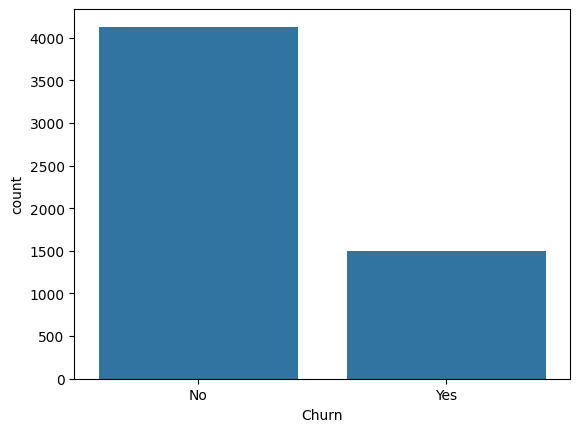

In [ ]:
# Target Variable Distribution (Churn)

sns.countplot(x='Churn', data=train_df)
train_df['Churn'].value_counts(normalize=True)

In [ ]:
# 📊 Insights:
# Majority customers do not churn
#  Dataset is imbalanced
#  Approx:
#   ~70% No
#   ~30% Yes

##### ii) Test data

,proportion
Churn,
No,0.740951
Yes,0.259049


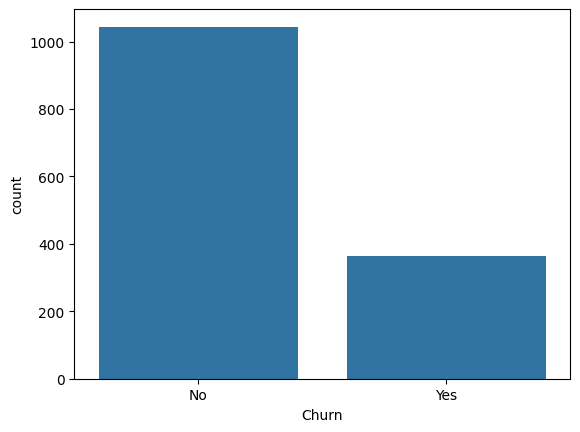

In [ ]:
# Target Variable Distribution (Churn)

sns.countplot(x='Churn', data=test_df)
test_df['Churn'].value_counts(normalize=True)

In [ ]:
# 📊 Insights:
# Majority customers do not churn
#  Dataset is imbalanced
#  Approx:
#   ~70% No
#   ~30% Yes

#### Categorical Feature Distribution

##### i) Train data

'gender is balanced'

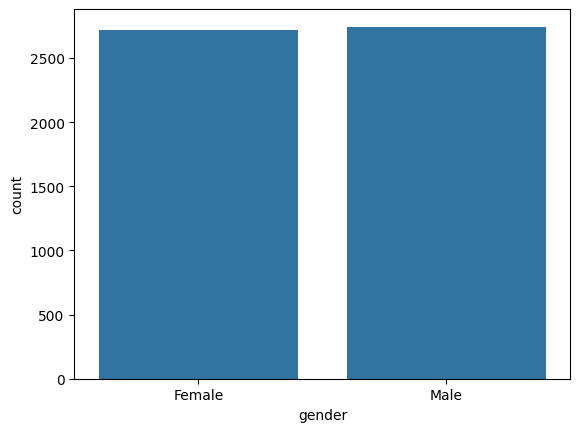

In [ ]:
sns.countplot(x='gender', data=train_df)

"""gender is balanced"""

'Customers without partners appear to churn more frequently than customers with partners,suggesting relationship stability may improve customer retention.\n'

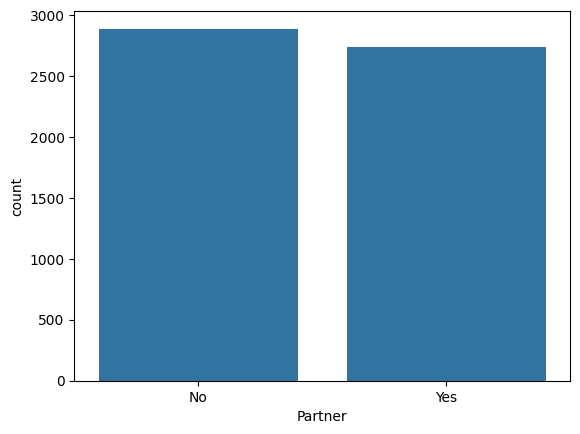

In [ ]:
sns.countplot(x='Partner', data=train_df)

"""Customers without partners appear to churn more frequently than customers with partners,suggesting relationship stability may improve customer retention.
"""

'Customers without dependents show higher churn rates, possibly because they have fewer long-term commitments.\n'

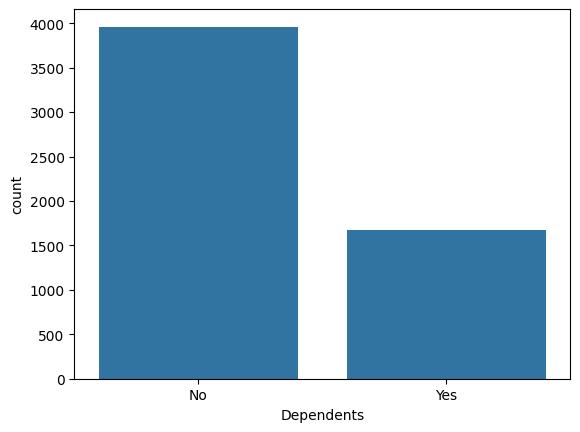

In [ ]:
sns.countplot(x='Dependents', data=train_df)

"""Customers without dependents show higher churn rates, possibly because they have fewer long-term commitments.
"""

'The count plot of PhoneService shows the distribution of customers who use phone services and those who do not. The majority of customers appear to have subscribed to\n    phone services, indicating that phone connectivity is a common service among telecom customers. Customers without phone service form a smaller portion of the dataset.\n   This feature may influence churn behavior because customers using more telecom services may show different retention patterns compared to customers with limited services.\n'

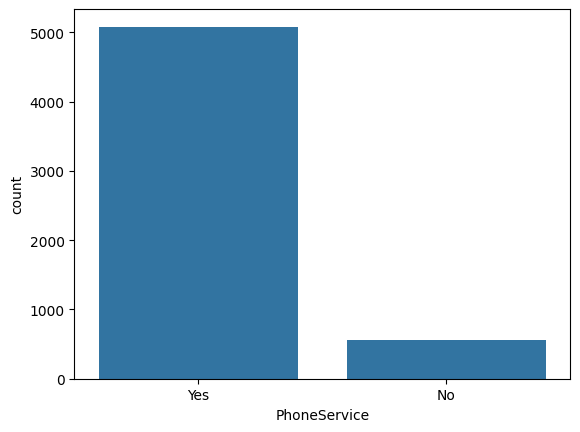

In [ ]:
sns.countplot(x='PhoneService', data=train_df)

"""The count plot of PhoneService shows the distribution of customers who use phone services and those who do not. The majority of customers appear to have subscribed to
    phone services, indicating that phone connectivity is a common service among telecom customers. Customers without phone service form a smaller portion of the dataset.
   This feature may influence churn behavior because customers using more telecom services may show different retention patterns compared to customers with limited services.
"""

'.Multiplelines shows somewhat balanced\n'

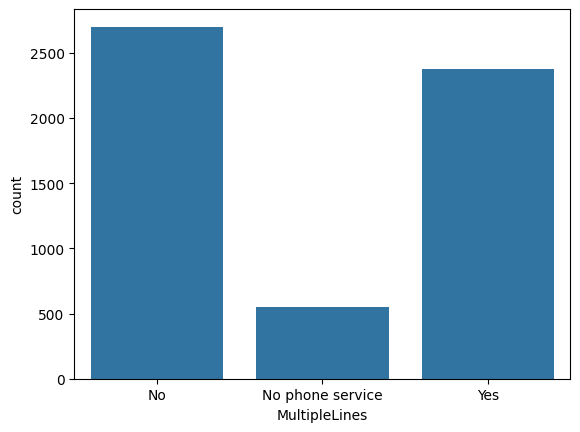

In [ ]:
sns.countplot(x='MultipleLines', data=train_df)

""".Multiplelines shows somewhat balanced
"""

'Internet usage:\nFiber optic and DSL dominate\nFew customers have no internet'

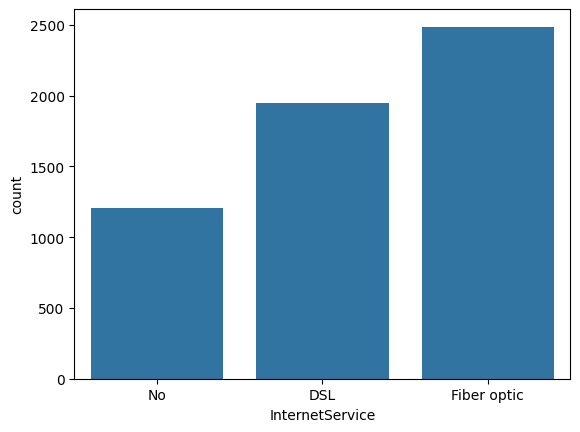

In [ ]:
sns.countplot(x='InternetService', data=train_df)

"""Internet usage:
Fiber optic and DSL dominate
Few customers have no internet"""

'Customers without tech support or online security services are more likely to churn,\n   suggesting additional services improve retention.\n'

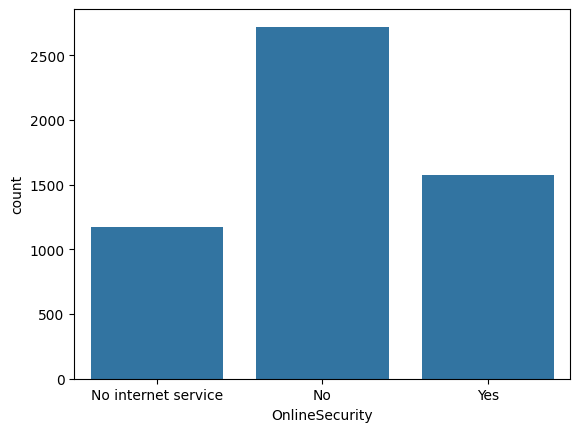

In [ ]:
sns.countplot(x='OnlineSecurity', data=train_df)

"""Customers without tech support or online security services are more likely to churn,
   suggesting additional services improve retention.
"""

'Customers who have Online Backup services are generally less likely to churn compared to customers who do not use backup services.\n'

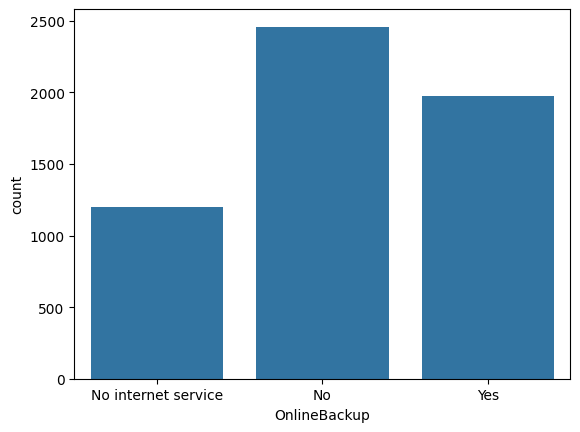

In [ ]:
sns.countplot(x='OnlineBackup', data=train_df)

"""Customers who have Online Backup services are generally less likely to churn compared to customers who do not use backup services.
"""

'.Device protection toggle stste\n'

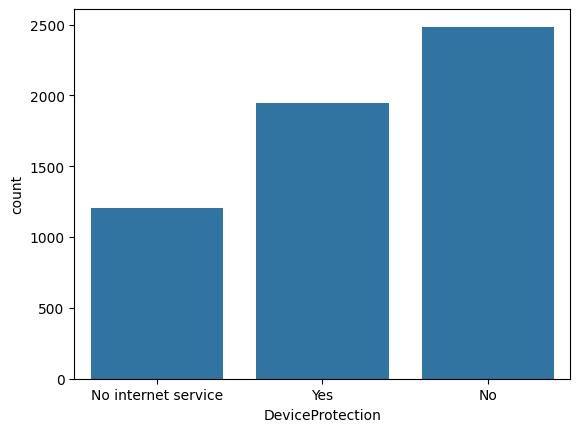

In [ ]:
sns.countplot(x='DeviceProtection', data=train_df)
""".Device protection toggle stste
"""

'Customers without tech support or online security services are more likely to churn,\n   suggesting additional services improve retention.\n'

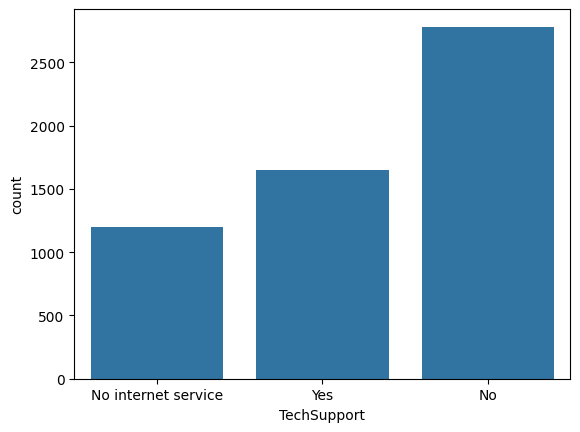

In [ ]:
sns.countplot(x='TechSupport', data=train_df)

"""Customers without tech support or online security services are more likely to churn,
   suggesting additional services improve retention.
"""

'Streaming tv is somewhat balanced\n'

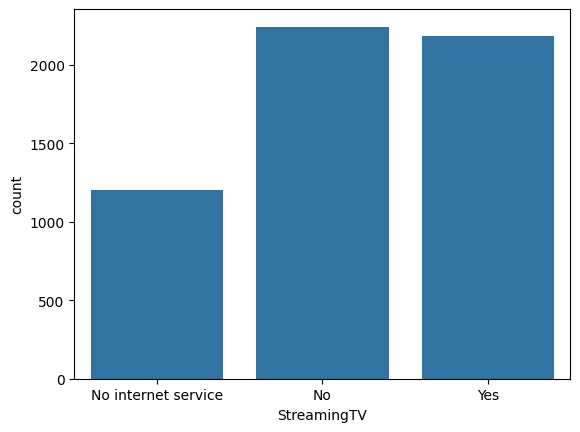

In [ ]:
sns.countplot(x='StreamingTV', data=train_df)
"""Streaming tv is somewhat balanced
"""

'StreamingMovies almost equal\n'

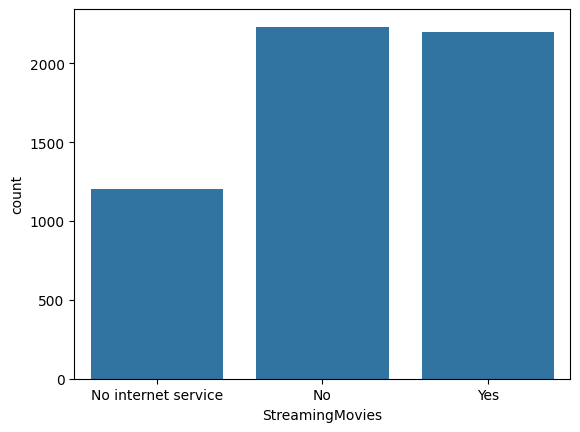

In [ ]:
sns.countplot(x='StreamingMovies', data=train_df)
"""StreamingMovies almost equal
"""

'Most customers use Month-to-month contracts'

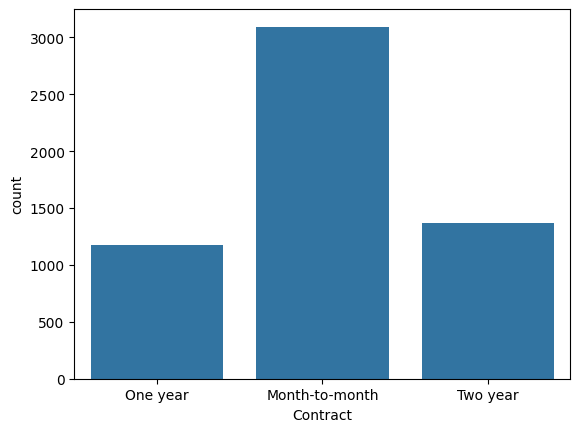

In [ ]:
sns.countplot(x='Contract', data=train_df)

"""Most customers use Month-to-month contracts"""

'Customers using paperless billing exhibit higher churn rates, which may indicate a preference for flexible or short-term service usage.\n'

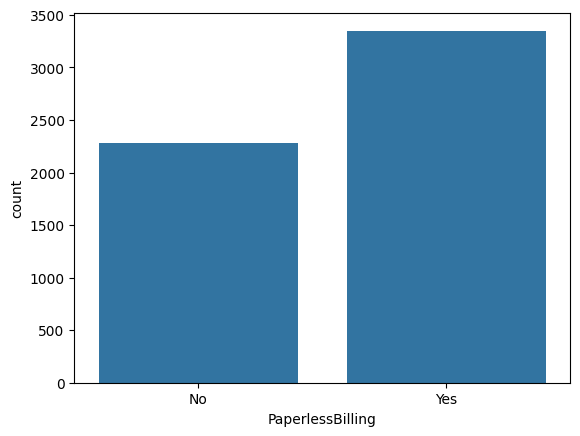

In [ ]:
sns.countplot(x='PaperlessBilling', data=train_df)

"""Customers using paperless billing exhibit higher churn rates, which may indicate a preference for flexible or short-term service usage.
"""

'Customers using electronic checks tend to churn more frequently compared to other payment methods.\n'

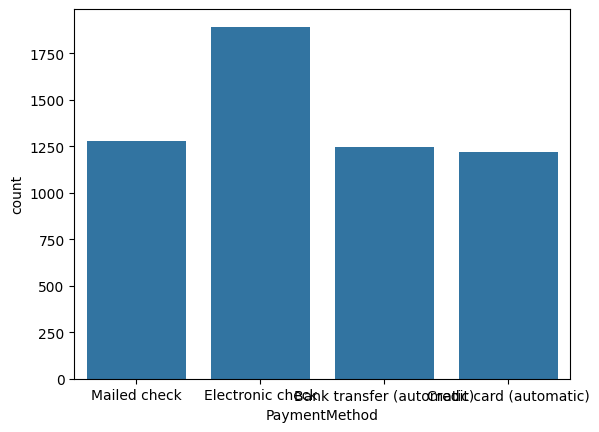

In [ ]:
sns.countplot(x='PaymentMethod', data=train_df)

"""Customers using electronic checks tend to churn more frequently compared to other payment methods.
"""

###### Categorical Features vs Churn

'Almost equal in gender '

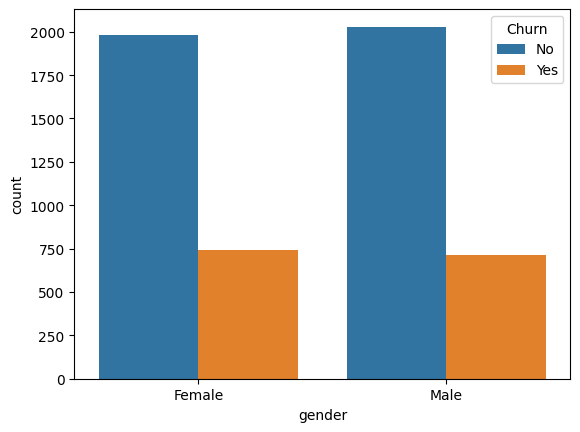

In [ ]:
sns.countplot(x='gender', hue='Churn', data=train_df)

"""Almost equal in gender """

'Customers with no partner churn more'

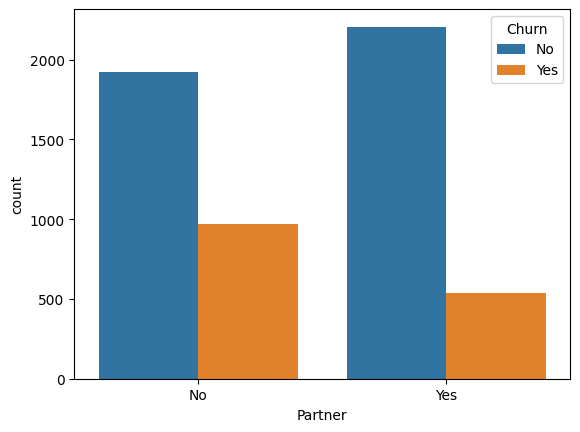

In [ ]:
sns.countplot(x='Partner', hue='Churn', data=train_df)

"""Customers with no partner churn more"""

'Customers with no dependents churn more'

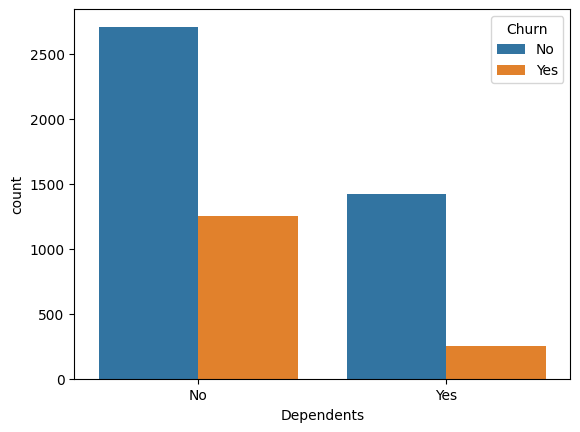

In [ ]:
sns.countplot(x='Dependents', hue='Churn', data=train_df)

"""Customers with no dependents churn more"""

'Phoneservice shows high '

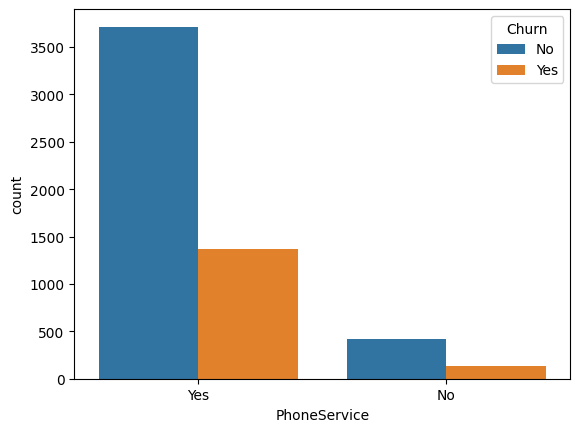

In [ ]:
sns.countplot(x='PhoneService', hue='Churn', data=train_df)

"""Phoneservice shows high """

'it is balanced'

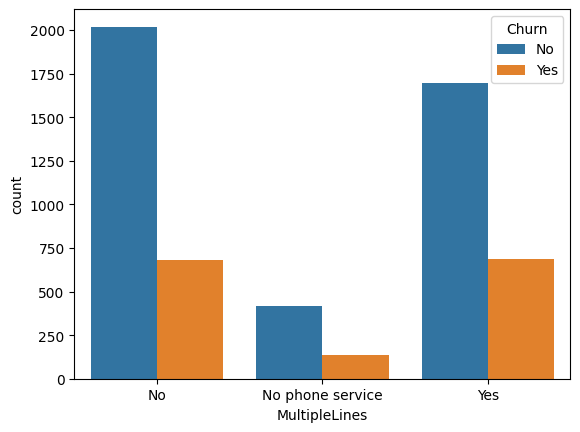

In [ ]:
sns.countplot(x='MultipleLines', hue='Churn', data=train_df)

"""it is balanced"""

'Fiber optic users show higher churn'

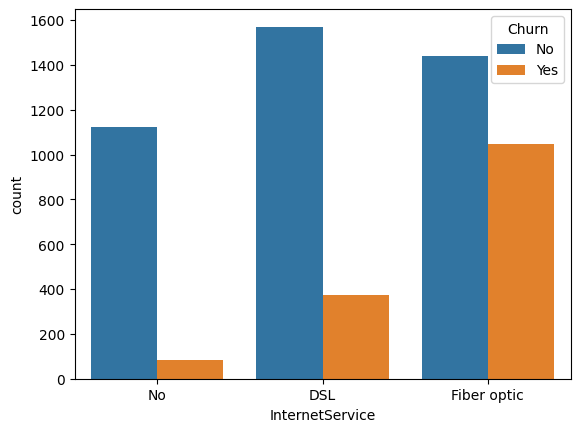

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=train_df)

"""Fiber optic users show higher churn"""

'Customers without security services churn more'

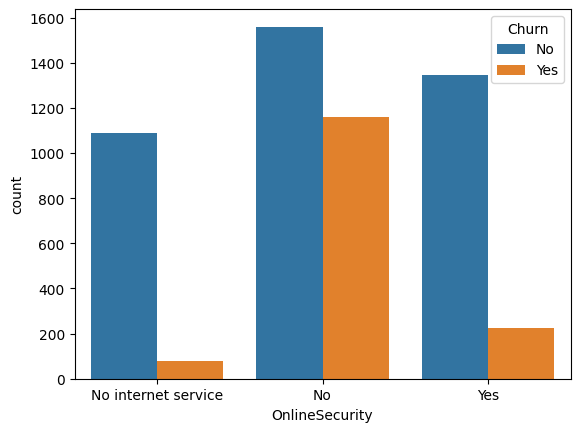

In [ ]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=train_df)

"""Customers without security services churn more"""

'Onlinebackup shows equal in opposite ways'

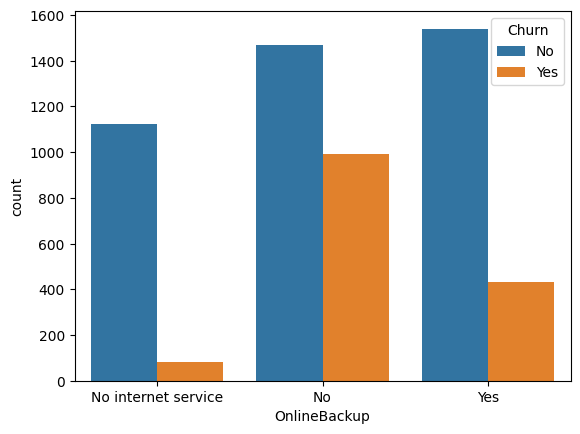

In [ ]:
sns.countplot(x='OnlineBackup', hue='Churn', data=train_df)

"""Onlinebackup shows equal in opposite ways"""

'Deviceprotection more churns to Yes'

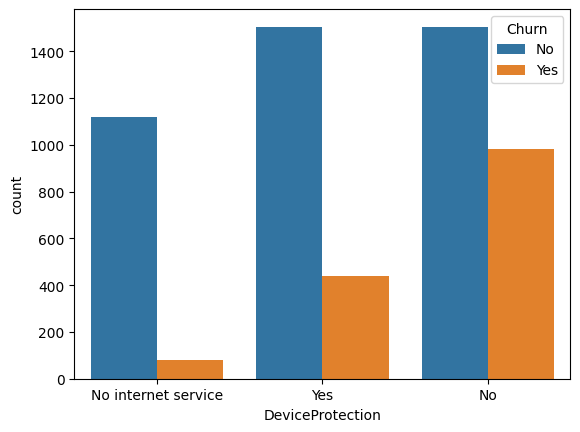

In [ ]:
sns.countplot(x='DeviceProtection', hue='Churn', data=train_df)

"""Deviceprotection more churns to Yes"""

'Lack of support → higher churn'

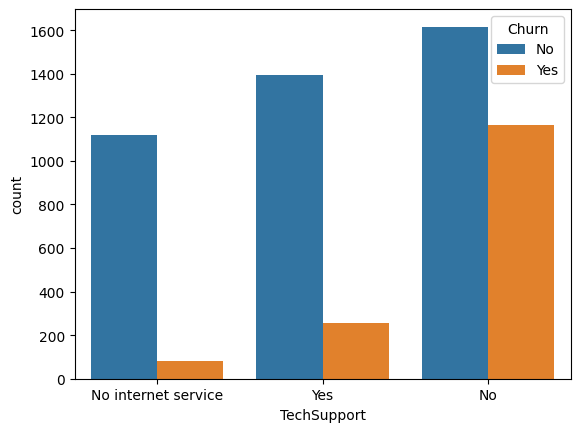

In [ ]:
sns.countplot(x='TechSupport', hue='Churn', data=train_df)

"""Lack of support → higher churn"""

'Streaming tv looks balanced'

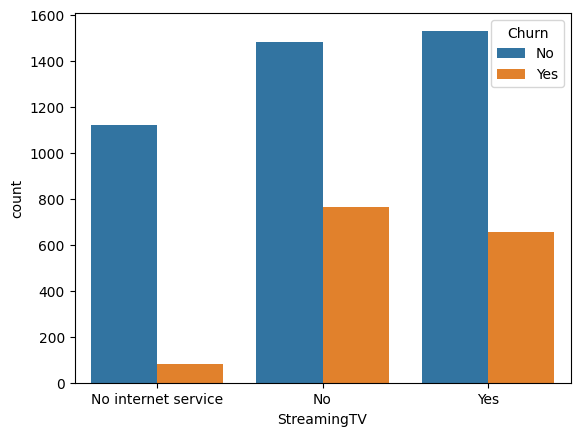

In [ ]:
sns.countplot(x='StreamingTV', hue='Churn', data=train_df)

"""Streaming tv looks balanced"""

'StreamingMovies ook balanced'

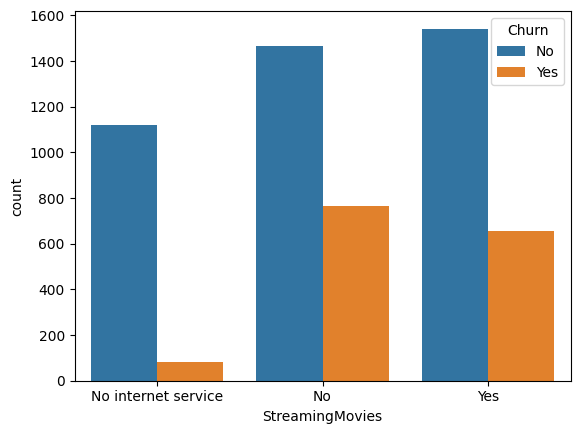

In [ ]:
sns.countplot(x='StreamingMovies', hue='Churn', data=train_df)

"""StreamingMovies ook balanced"""

'Customers with month-to-month contracts have higher churn'

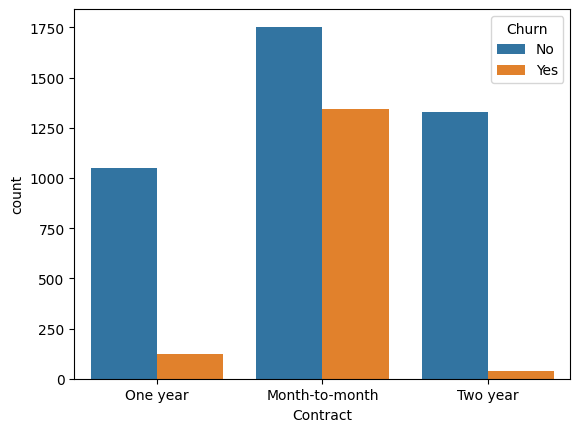

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=train_df)

"""Customers with month-to-month contracts have higher churn"""

'More churns to Yes'

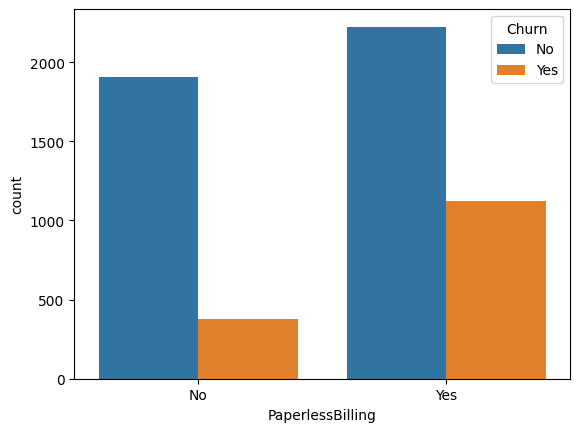

In [ ]:
sns.countplot(x='PaperlessBilling', hue='Churn', data=train_df)

"""More churns to Yes"""

'it looks equal distribution'

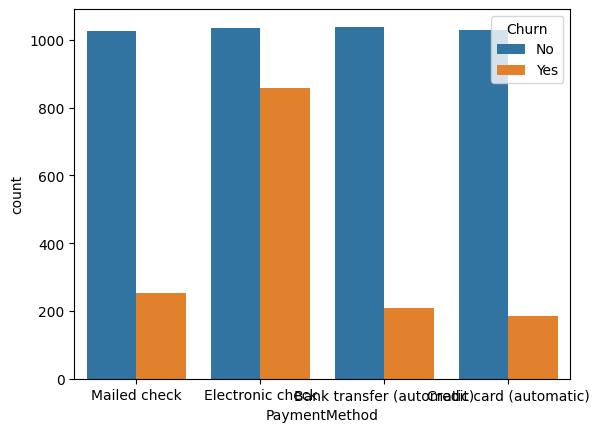

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=train_df)

"""it looks equal distribution"""

##### i) Test data

'gender is balanced'

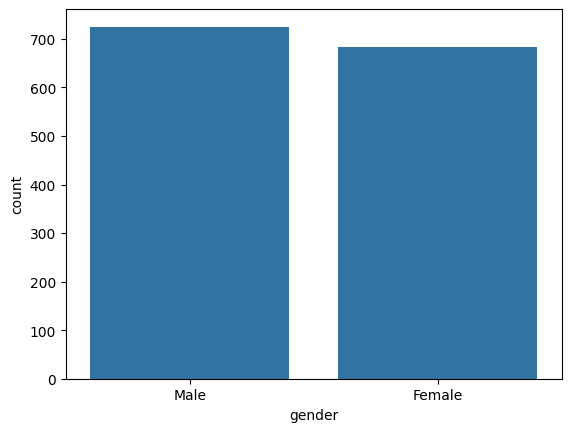

In [ ]:
sns.countplot(x='gender', data=test_df)

"""gender is balanced"""

'Balnced\n'

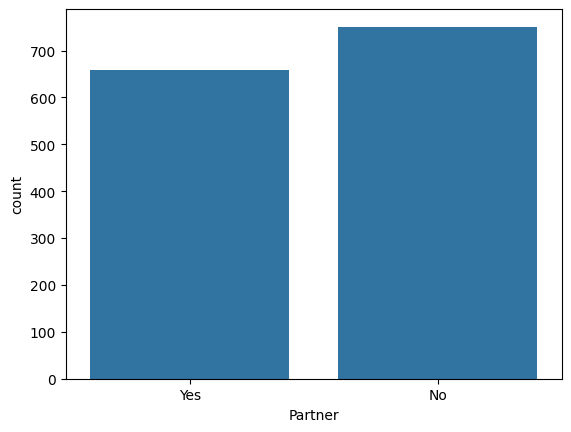

In [ ]:
sns.countplot(x='Partner', data=test_df)

"""Balnced
"""

'imbalanced\n'

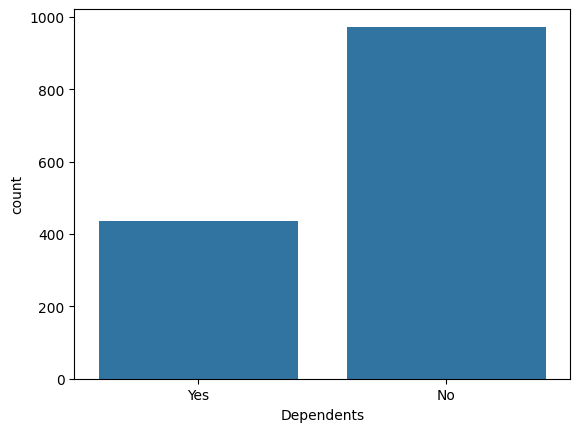

In [ ]:
sns.countplot(x='Dependents', data=test_df)

"""imbalanced
"""

'More Yes\n'

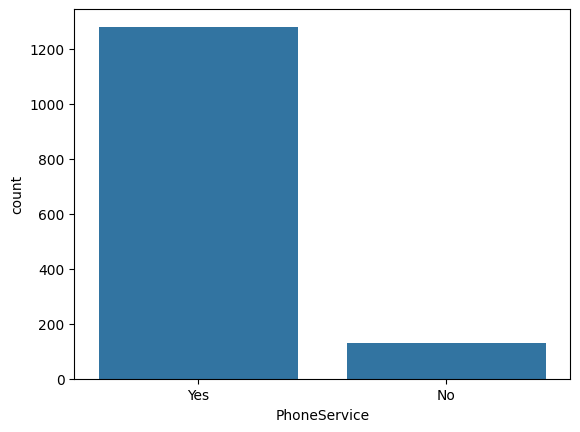

In [ ]:
sns.countplot(x='PhoneService', data=test_df)

"""More Yes
"""

'XLooks balanced\n'

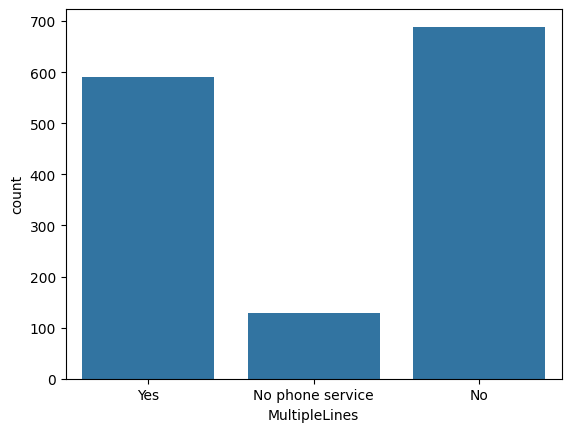

In [ ]:
sns.countplot(x='MultipleLines', data=test_df)

"""XLooks balanced
"""

'Internet usage:\nFiber optic and DSL dominate\nFew customers have no internet'

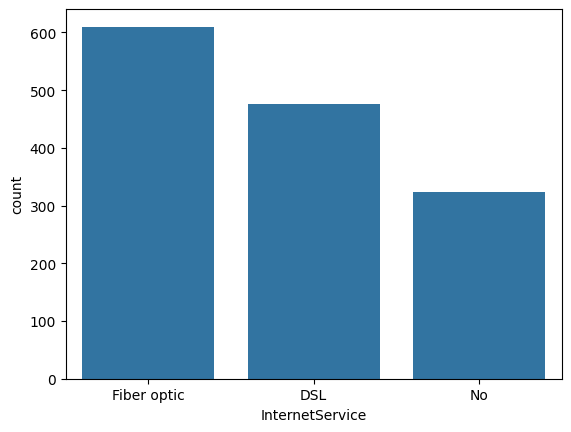

In [ ]:
sns.countplot(x='InternetService', data=test_df)

"""Internet usage:
Fiber optic and DSL dominate
Few customers have no internet"""

'Online security more on yes\n'

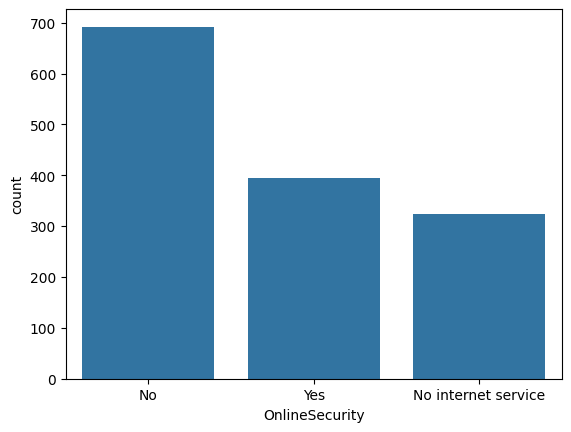

In [ ]:
sns.countplot(x='OnlineSecurity', data=test_df)

"""Online security more on yes
"""

'Not equal distribution\n'

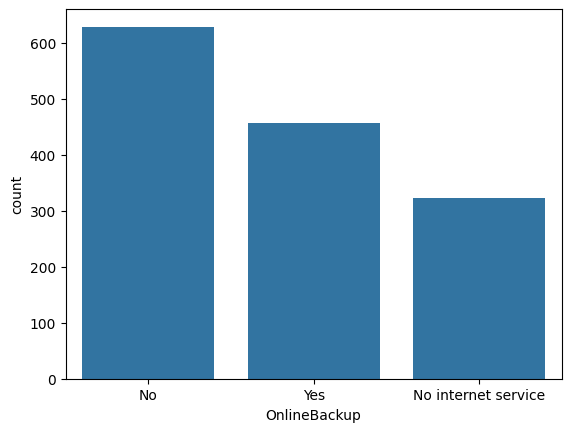

In [ ]:
sns.countplot(x='OnlineBackup', data=test_df)
"""Not equal distribution
"""

'Not equal distribution\n'

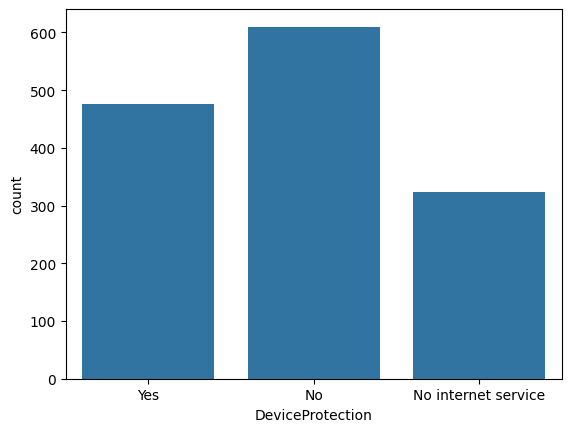

In [ ]:
sns.countplot(x='DeviceProtection', data=test_df)
"""Not equal distribution
"""

'Not equal distribution\n'

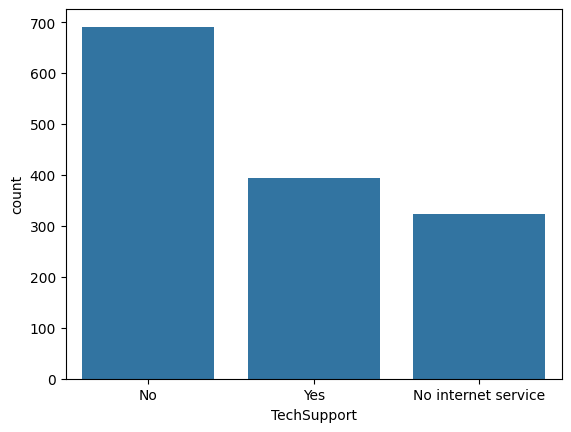

In [ ]:
sns.countplot(x='TechSupport', data=test_df)
"""Not equal distribution
"""

'Not equal distribution\n'

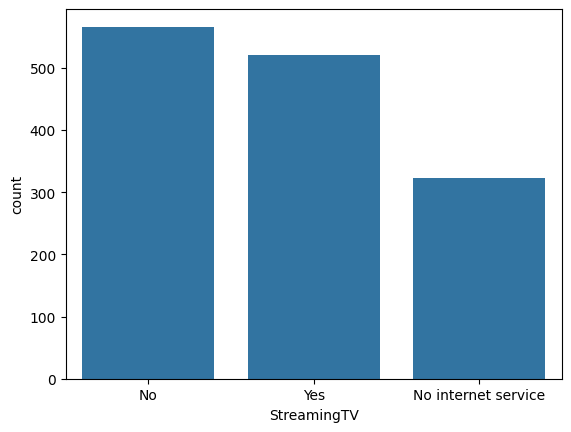

In [ ]:
sns.countplot(x='StreamingTV', data=test_df)
"""Not equal distribution
"""

'almodt equal distribution on Yes and No\n'

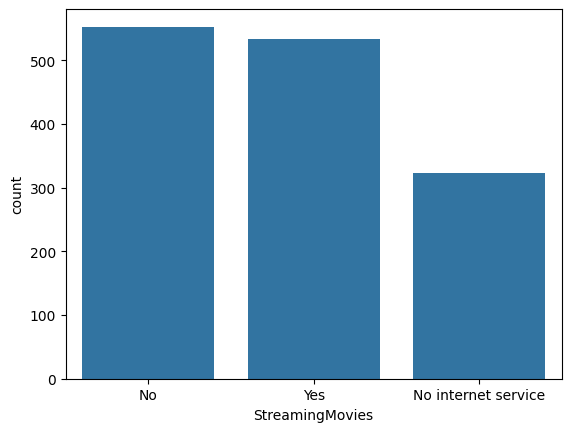

In [ ]:
sns.countplot(x='StreamingMovies', data=test_df)
"""almodt equal distribution on Yes and No
"""

'Most customers use Month-to-month contracts'

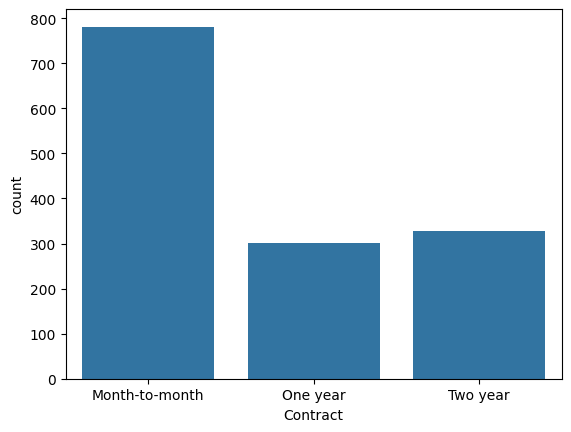

In [ ]:
sns.countplot(x='Contract', data=test_df)

"""Most customers use Month-to-month contracts"""

'Balanced\n'

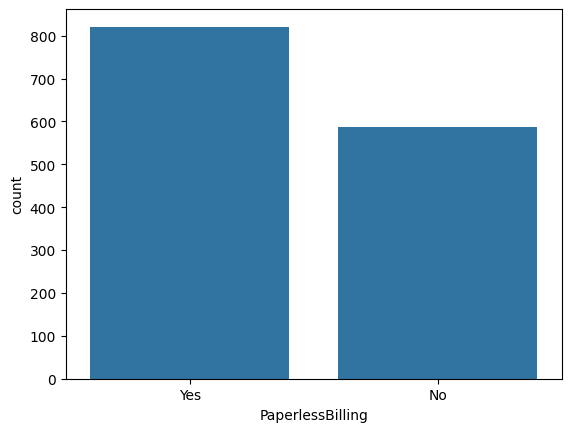

In [ ]:
sns.countplot(x='PaperlessBilling', data=test_df)

"""Balanced
"""

'unequal\n'

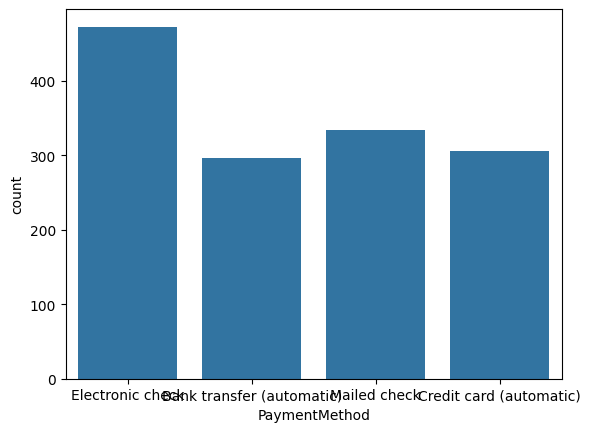

In [ ]:
sns.countplot(x='PaymentMethod', data=test_df)

"""unequal
"""

###### Categorical Features vs Churn

'more equal'

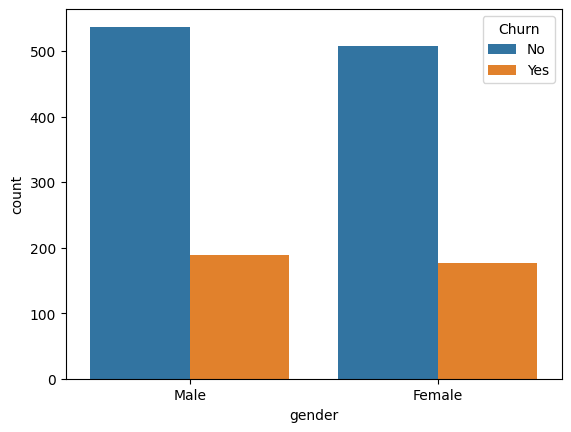

In [ ]:
sns.countplot(x='gender', hue='Churn', data=test_df)

"""more equal"""

'Customers with no partner churn more'

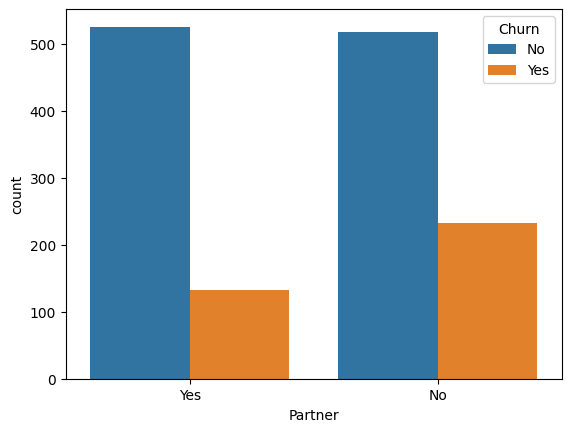

In [ ]:
sns.countplot(x='Partner', hue='Churn', data=test_df)

"""Customers with no partner churn more"""

'Customers with no dependents churn more'

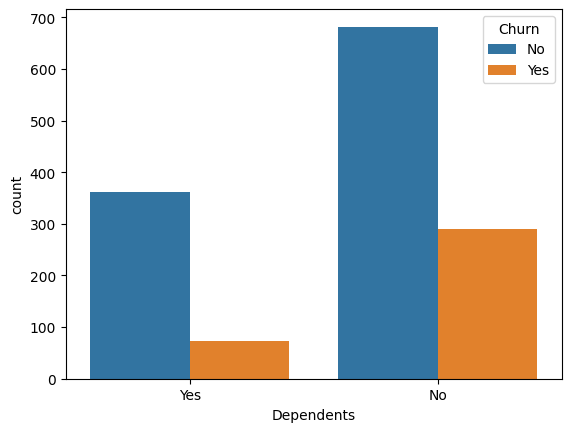

In [ ]:
sns.countplot(x='Dependents', hue='Churn', data=test_df)

"""Customers with no dependents churn more"""

'More to Yes'

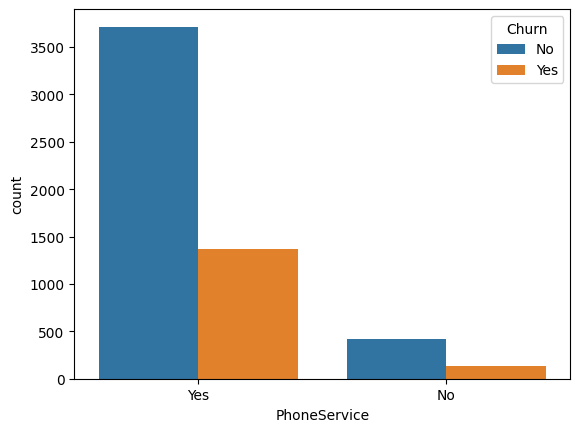

In [ ]:
sns.countplot(x='PhoneService', hue='Churn', data=train_df)

"""More to Yes"""

'unequal'

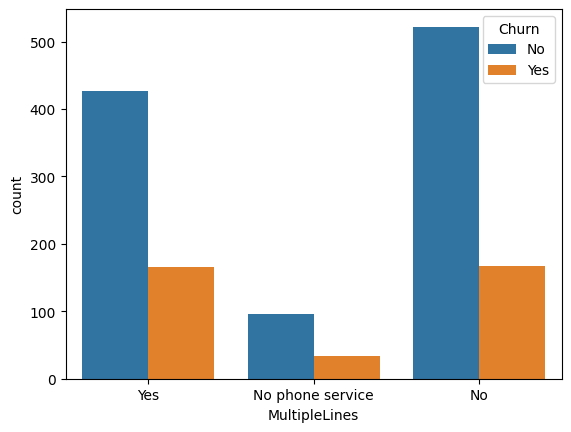

In [ ]:
sns.countplot(x='MultipleLines', hue='Churn', data=test_df)

"""unequal"""

'Fiber optic users show higher churn'

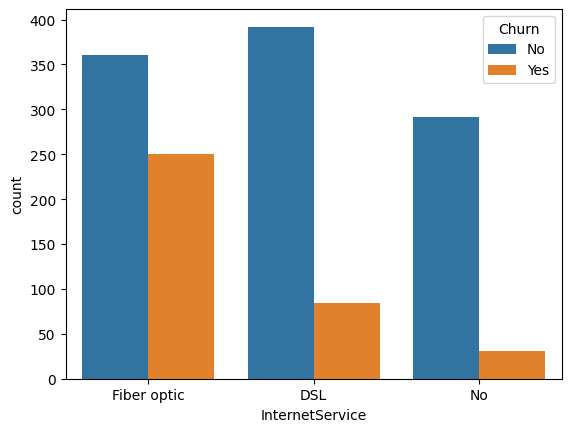

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=test_df)

"""Fiber optic users show higher churn"""

'Customers without security services churn more'

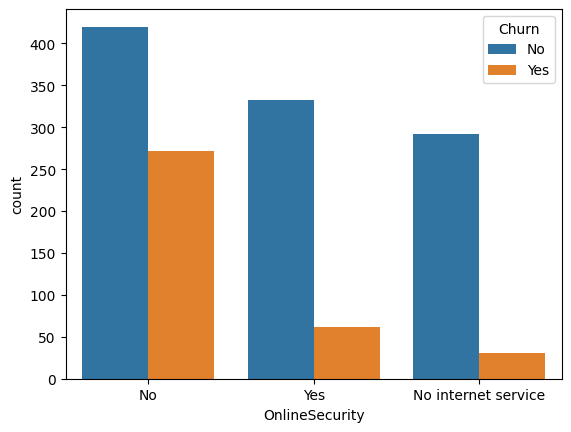

In [ ]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=test_df)

"""Customers without security services churn more"""

'not symmetrc'

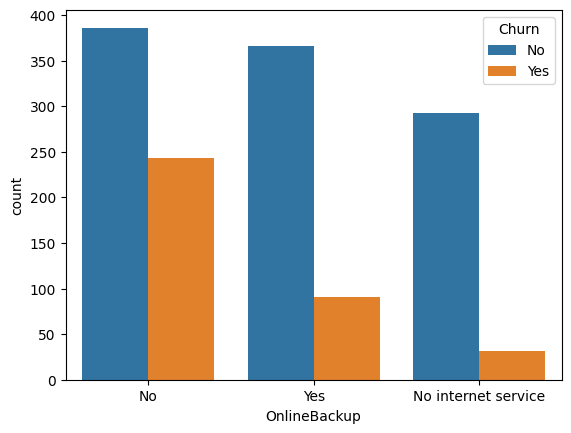

In [ ]:
sns.countplot(x='OnlineBackup', hue='Churn', data=test_df)

"""not symmetrc"""

'not equal'

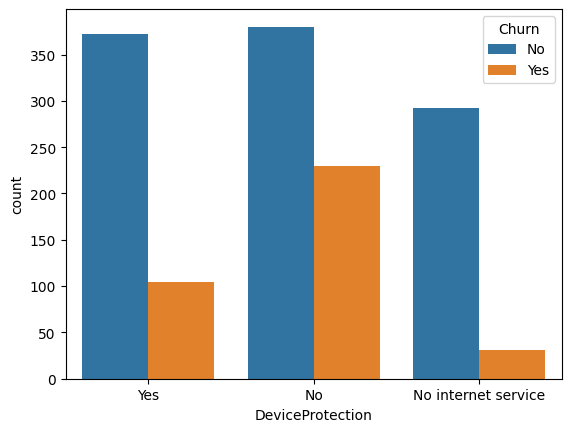

In [ ]:
sns.countplot(x='DeviceProtection', hue='Churn', data=test_df)

"""not equal"""

'Lack of support → higher churn'

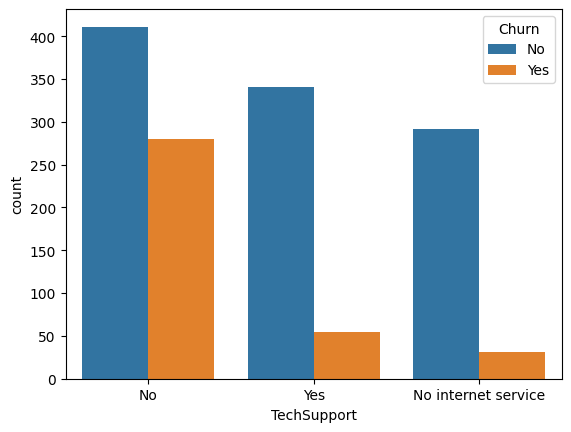

In [ ]:
sns.countplot(x='TechSupport', hue='Churn', data=test_df)

"""Lack of support → higher churn"""

'Not same'

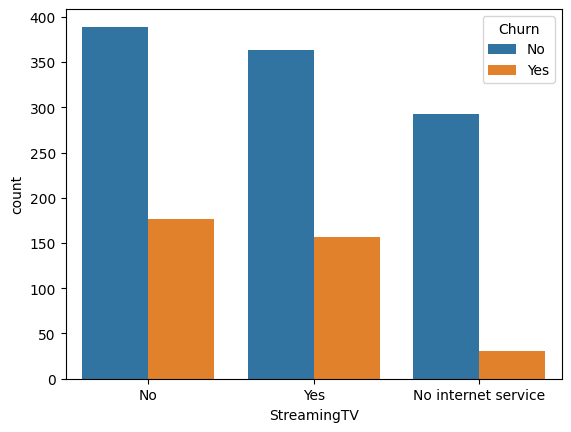

In [ ]:
sns.countplot(x='StreamingTV', hue='Churn', data=test_df)

"""Not same"""

'unequal'

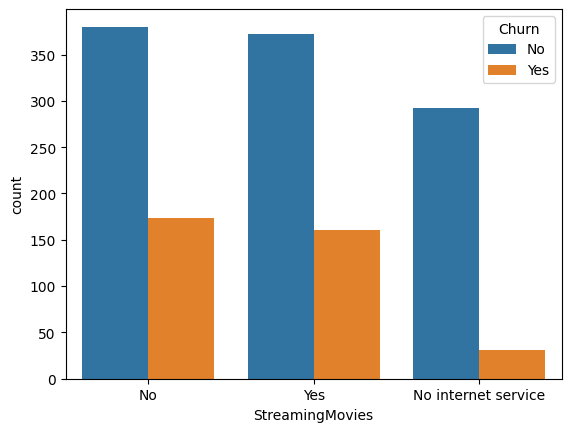

In [ ]:
sns.countplot(x='StreamingMovies', hue='Churn', data=test_df)

"""unequal"""

'Customers with month-to-month contracts have higher churn'

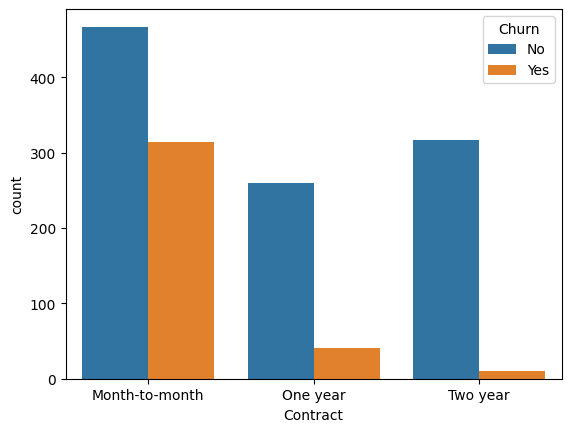

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=test_df)

"""Customers with month-to-month contracts have higher churn"""

'almost symmetrical'

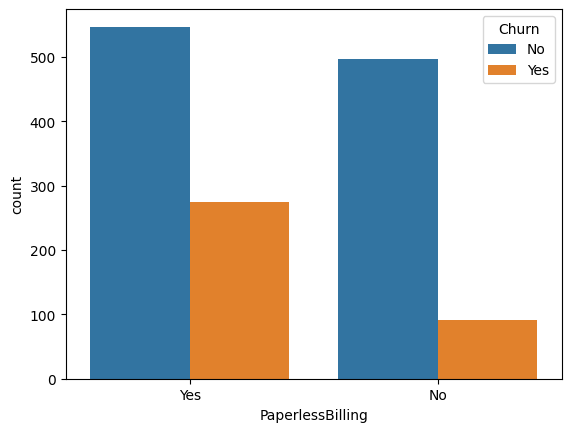

In [ ]:
sns.countplot(x='PaperlessBilling', hue='Churn', data=test_df)

"""almost symmetrical"""

'equal'

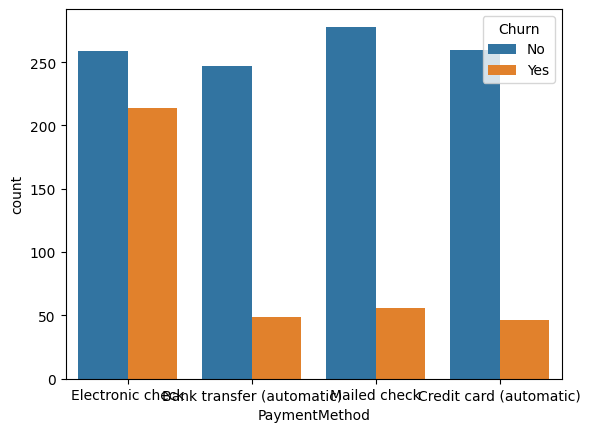

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=test_df)

"""equal"""

#### Numerical Feature Distribution

##### i) Train data

'0 is more than 1\n'

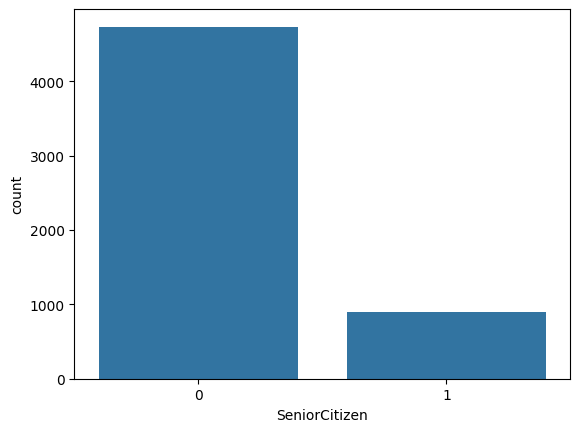

In [ ]:
sns.countplot(x='SeniorCitizen', data=train_df)

"""0 is more than 1
"""

'Right-skewed  Many customers are new (low tenure)'

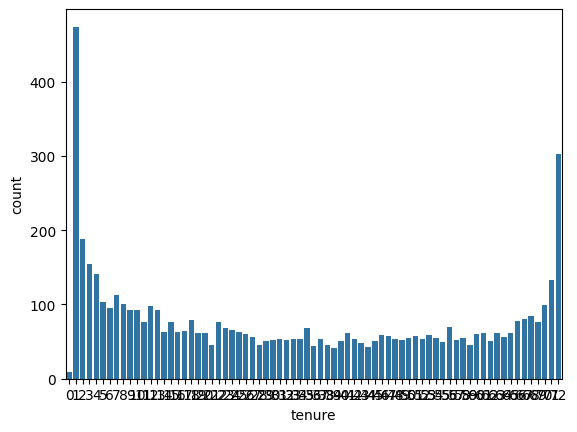

In [ ]:
sns.countplot(x ='tenure', data=train_df)

"""Right-skewed  Many customers are new (low tenure)"""

'Slightly skewed distribution\n'

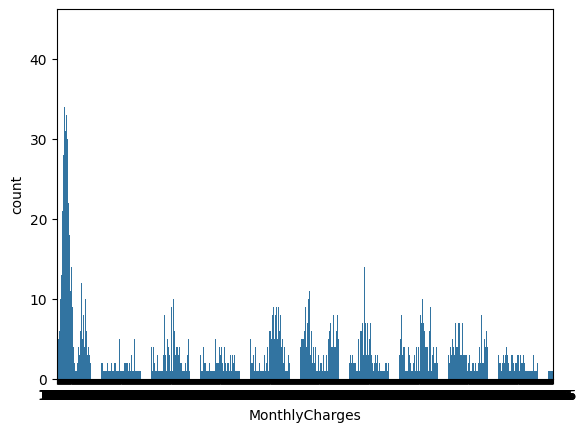

In [ ]:
sns.countplot(x='MonthlyCharges', data=train_df)

"""Slightly skewed distribution
"""

'Wide spread (increasing with tenure)'

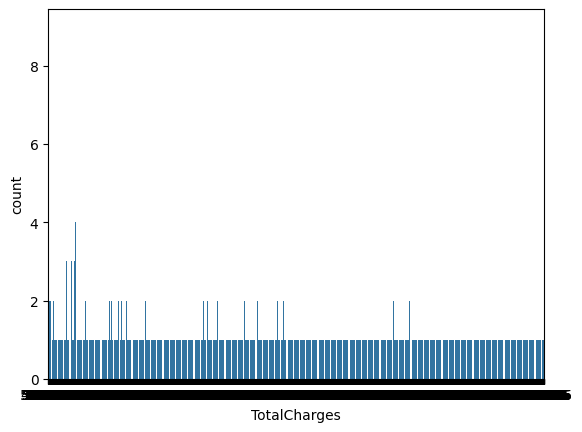

In [ ]:
sns.countplot(x='TotalCharges', data=train_df)

"""Wide spread (increasing with tenure)"""

###### Numerical Features vs Churn

'Customers with low tenure churn more'

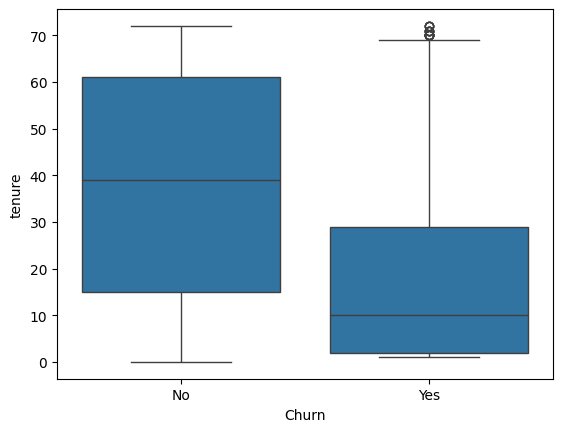

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=train_df)

"""Customers with low tenure churn more"""

'Customers with higher monthly charges churn more'

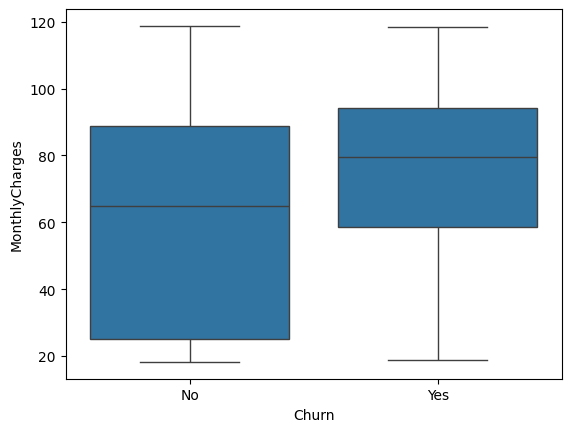

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=train_df)

"""Customers with higher monthly charges churn more"""

'Lower total charges (new customers) → higher churn'

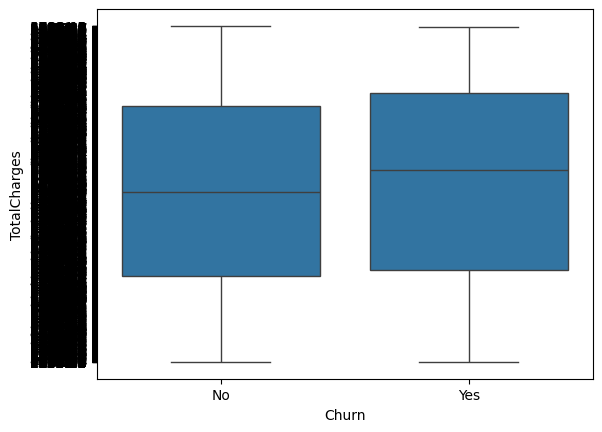

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=train_df)

"""Lower total charges (new customers) → higher churn"""

##### ii) Test data

'Higher\n'

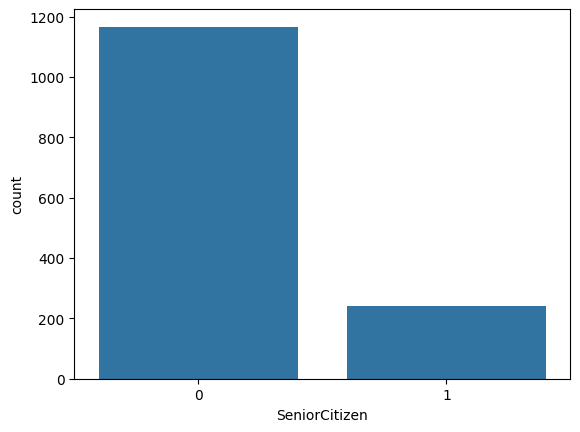

In [ ]:
sns.countplot(x='SeniorCitizen', data=test_df)

"""Higher
"""

'Right-skewed  Many customers are new (low tenure)'

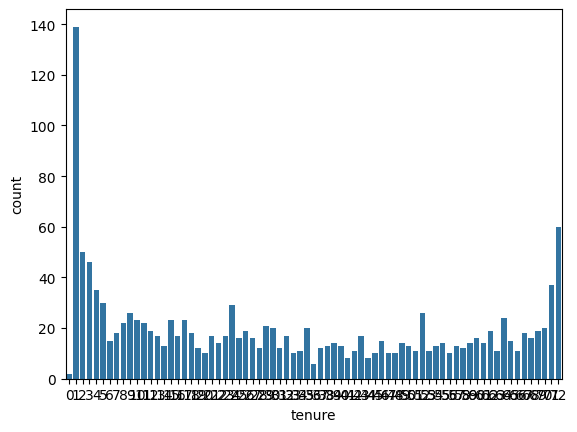

In [ ]:
sns.countplot(x ='tenure', data=test_df)

"""Right-skewed  Many customers are new (low tenure)"""

'Slightly skewed distribution\n'

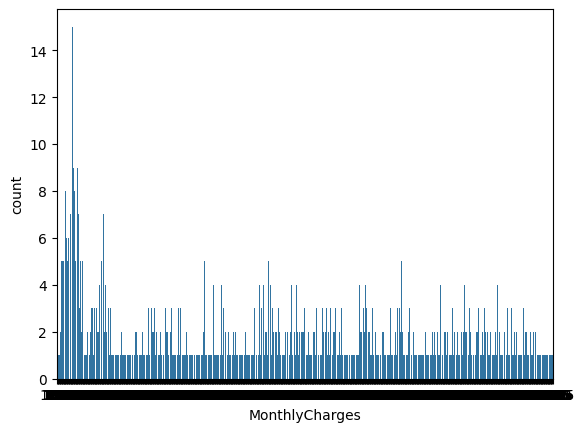

In [ ]:
sns.countplot(x='MonthlyCharges', data=test_df)

"""Slightly skewed distribution
"""

'Wide spread (increasing with tenure)'

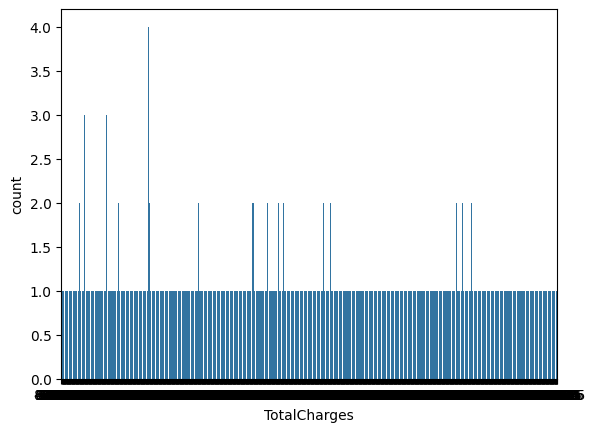

In [ ]:
sns.countplot(x='TotalCharges', data=test_df)

"""Wide spread (increasing with tenure)"""

###### Numerical Features vs Churn

'Customers with low tenure churn more'

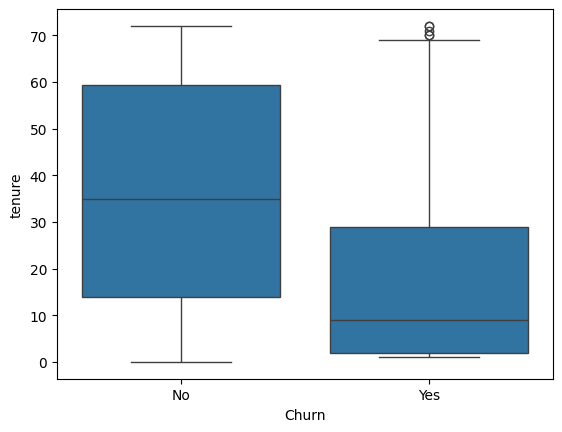

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=test_df)

"""Customers with low tenure churn more"""

'Customers with higher monthly charges churn more'

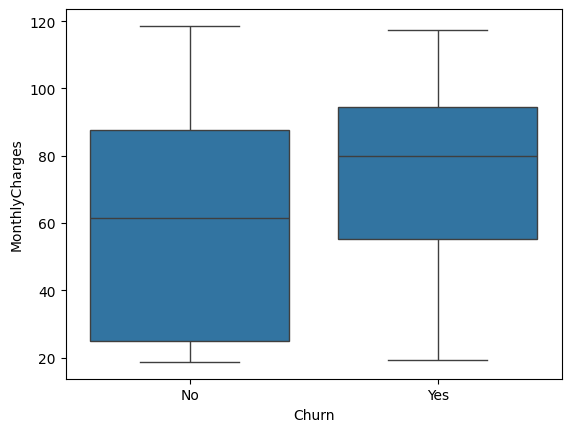

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=test_df)

"""Customers with higher monthly charges churn more"""

'Lower total charges (new customers) → higher churn'

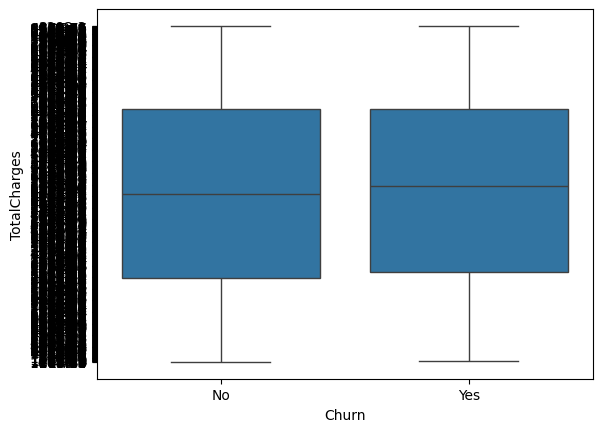

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=test_df)

"""Lower total charges (new customers) → higher churn"""

### b) Identify missing values, outliers, and other data quality issues.

#### i) Check missing values / null values

##### i) Train data

In [ ]:
# Detecting missing values in the dataset.

train_df.isna()   # customer_df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5630,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5631,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5632,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Summary of Missing Values in the Column

train_df.isna().sum()  # customer_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


###### Hidden missing values

In [ ]:
# TotalCharges has hidden missing values stored as blanks

train_df['TotalCharges'].unique()   # Stored as object instead of numeric


array(['700.45', '961.4', '5581.05', ..., '1322.85', '5555.3', '1381.8'],
      dtype=object)

##### i) Test data

In [ ]:
# Detecting missing values in the dataset.

test_df.isna()   # customer_df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1405,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1406,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1407,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Summary of Missing Values in the Column

test_df.isna().sum()  # customer_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# No missing values in the test dataset

###### Hidden missing values

In [ ]:
# TotalCharges has hidden missing values stored as blanks

train_df['TotalCharges'].unique()   # Stored as object instead of numeric


array(['700.45', '961.4', '5581.05', ..., '1322.85', '5555.3', '1381.8'],
      dtype=object)

#### ii) Outlier Detection

##### Splitting the Columns into Numerical & Categorical Columns

###### i) Train data

In [ ]:
# Splitting the Columns into Numerical & Categorical Columns

num1_cols = train_df.select_dtypes(include= ['number'])
cat1_cols = train_df.select_dtypes(include= ['object'])

In [ ]:
# Selecting the numerical columns (int, float)

num1_cols

,SeniorCitizen,tenure,MonthlyCharges
0,0,35,20.75
1,0,28,35.75
2,0,56,98.60
3,0,39,20.45
4,0,43,51.25
...,...,...,...
5629,0,51,99.00
5630,1,68,41.95
5631,0,72,19.95
5632,0,69,82.45


In [ ]:
# Selecting the categorical/text columns

cat1_cols

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,9509-MPYOD,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,700.45,No
1,7746-AWNQW,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,961.4,No
2,2208-UGTGR,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,5581.05,No
3,4884-LEVMQ,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),790,No
4,6682-VCIXC,Female,Yes,Yes,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,No,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,5038.15,No
5630,3908-MKIMJ,Male,Yes,No,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,2965.75,No
5631,4277-BWBML,Male,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),1322.85,No
5632,9110-HSGTV,Female,No,No,Yes,No,DSL,NaN,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),5555.3,No


In [ ]:
# Displaying the first 5 Numerical columns (int, float)

num1_cols.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,35,20.75
1,0,28,35.75
2,0,56,98.60
3,0,39,20.45
4,0,43,51.25


In [ ]:
# Displaying the first 5 categorical/text columns

cat1_cols.head()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,9509-MPYOD,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,700.45,No
1,7746-AWNQW,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,961.4,No
2,2208-UGTGR,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,5581.05,No
3,4884-LEVMQ,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),790,No
4,6682-VCIXC,Female,Yes,Yes,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),2151.6,No


In [ ]:
# Separating Columns based on their data types.

num1_cols = train_df.select_dtypes(include= ['number']).columns
cat1_cols = train_df.select_dtypes(include= ['object']).columns

In [ ]:
num1_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
cat1_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

###### i) Test data

In [ ]:
# Splitting the Columns into Numerical & Categorical Columns

num2_cols = train_df.select_dtypes(include= ['number'])
cat2_cols = train_df.select_dtypes(include= ['object'])

In [ ]:
# Selecting the numerical columns (int, float)

num2_cols

,SeniorCitizen,tenure,MonthlyCharges
0,0,35,20.75
1,0,28,35.75
2,0,56,98.60
3,0,39,20.45
4,0,43,51.25
...,...,...,...
5629,0,51,99.00
5630,1,68,41.95
5631,0,72,19.95
5632,0,69,82.45


In [ ]:
# Selecting the categorical/text columns

cat2_cols

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,9509-MPYOD,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,700.45,No
1,7746-AWNQW,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,961.4,No
2,2208-UGTGR,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,5581.05,No
3,4884-LEVMQ,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),790,No
4,6682-VCIXC,Female,Yes,Yes,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,No,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,5038.15,No
5630,3908-MKIMJ,Male,Yes,No,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,2965.75,No
5631,4277-BWBML,Male,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),1322.85,No
5632,9110-HSGTV,Female,No,No,Yes,No,DSL,NaN,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),5555.3,No


In [ ]:
# Displaying the first 5 Numerical columns (int, float)

num2_cols.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,35,20.75
1,0,28,35.75
2,0,56,98.60
3,0,39,20.45
4,0,43,51.25


In [ ]:
# Displaying the first 5 categorical/text columns

cat2_cols.head()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,9509-MPYOD,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,700.45,No
1,7746-AWNQW,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,961.4,No
2,2208-UGTGR,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,5581.05,No
3,4884-LEVMQ,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),790,No
4,6682-VCIXC,Female,Yes,Yes,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),2151.6,No


In [ ]:
# Separating Columns based on their data types.

num2_cols = train_df.select_dtypes(include= ['number']).columns
cat2_cols = train_df.select_dtypes(include= ['object']).columns

In [ ]:
num2_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
cat2_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

##### Outlier Detection

###### i) Train Data

In [ ]:
# Quartiles & IQR plays a role in identifying Outliers


# Q1 = 25% of the column (25th percentile)
# Q1 = 50% of the column (50th percentile)
# Q1 = 75% of the column (75th percentile)

# Range = Max -Min
# IQR = Q3 - Q1
# IQR : Inter Quartile Range.

# Upper limit = Q3 + (1.5 *IQR)
# Lower limit = Q3 - (1.5 *IQR)

# Outlier : any value > Upper limit or Value <Lower limit
# we handle outliers because, they can skew the general nature
# of the ML model

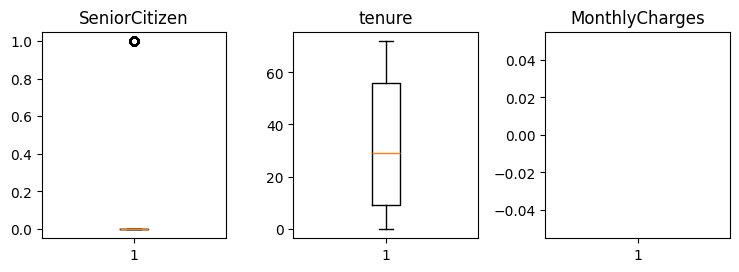

In [ ]:
# We use Boxplot to Identify outliers by subplots

plt.figure(figsize=(7.5,7.5))

for i, col in enumerate(num1_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# IQR-based outlier detection pipeline

# These are calculated column-wise for all numerical columns.

# 1. Calculate Quartiles
Q1 = train_df[num1_cols].quantile(0.25)  # Q1 (25th percentile): value below which 25% of data lies
Q3 = train_df[num1_cols].quantile(0.75)  # Q1 (75th percentile): value below which 75% of data lies

# 2. Compute IQR
IQR = Q3 - Q1              # IQR (Interquartile Range) = spread of middle 50% of data
                           # Helps define “normal range”

IQR

# 3. Define Limits                # These define acceptable boundaries    # Anything outside = outlier
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

# 4. Detect Outliers
outliers = ((train_df[num1_cols] > upper_limit) | (train_df[num1_cols] < lower_limit))

outliers

,SeniorCitizen,tenure,MonthlyCharges
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
5629,False,False,False
5630,True,False,False
5631,False,False,False
5632,False,False,False


###### i) Test Data

In [ ]:
# Quartiles & IQR plays a role in identifying Outliers


# Q1 = 25% of the column (25th percentile)
# Q1 = 50% of the column (50th percentile)
# Q1 = 75% of the column (75th percentile)

# Range = Max -Min
# IQR = Q3 - Q1
# IQR : Inter Quartile Range.

# Upper limit = Q3 + (1.5 *IQR)
# Lower limit = Q3 - (1.5 *IQR)

# Outlier : any value > Upper limit or Value <Lower limit
# we handle outliers because, they can skew the general nature
# of the ML model

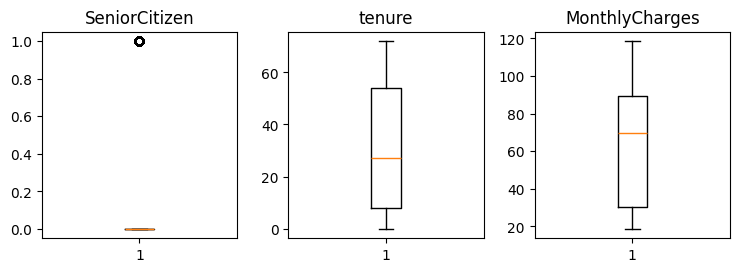

In [ ]:
# We use Boxplot to Identify outliers by subplots

plt.figure(figsize=(7.5,7.5))

for i, col in enumerate(num2_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(test_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# IQR-based outlier detection pipeline

# These are calculated column-wise for all numerical columns.

# 1. Calculate Quartiles
Q1 = train_df[num2_cols].quantile(0.25)  # Q1 (25th percentile): value below which 25% of data lies
Q3 = train_df[num2_cols].quantile(0.75)  # Q1 (75th percentile): value below which 75% of data lies

# 2. Compute IQR
IQR = Q3 - Q1              # IQR (Interquartile Range) = spread of middle 50% of data
                           # Helps define “normal range”

IQR

# 3. Define Limits                # These define acceptable boundaries    # Anything outside = outlier
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

# 4. Detect Outliers
outliers = ((test_df[num2_cols] > upper_limit) | (test_df[num2_cols] < lower_limit))

outliers

,SeniorCitizen,tenure,MonthlyCharges
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
1404,False,False,False
1405,True,False,False
1406,False,False,False
1407,False,False,False


#### iii) Data Quality Issues

##### Checking the Unique values of all   Columns


###### i) Train data

In [ ]:
cat1_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
train_df['customerID'].unique()  # Unique for every row (Drop it - not useful for prediction)

array(['9509-MPYOD', '7746-AWNQW', '2208-UGTGR', ..., '4277-BWBML',
       '9110-HSGTV', '3402-XRIUO'], dtype=object)

In [ ]:
train_df['customerID'].nunique()

5634

In [ ]:
train_df['gender'].unique() # Clean, no issue

array(['Female', 'Male', nan], dtype=object)

In [ ]:
train_df['SeniorCitizen'].unique()  # Already numeric (binary)

array([0, 1])

In [ ]:
train_df['Partner'].unique() # Convert to 0/1 later

array(['No', 'Yes'], dtype=object)

In [ ]:
train_df['Dependents'].unique() # Convert to 0/1 later

array(['No', 'Yes'], dtype=object)

In [ ]:
train_df['tenure'].unique() # Numerical

array([35, 28, 56, 39, 43,  2, 18, 63, 40, 53, 48, 72, 61,  6, 21,  9,  3,
       58, 57, 17, 30, 20,  4, 16, 71, 38,  5, 13, 55, 60, 37,  1,  7, 11,
       12, 67, 54,  8, 22, 65, 36, 50, 23, 49, 69, 70, 25, 14, 10, 52, 68,
       33, 24, 66, 59, 32, 27, 29, 45, 42, 64, 62, 19, 41, 51, 44, 34, 26,
       47, 31, 15, 46,  0])

In [ ]:
train_df['tenure'].nunique()

73

In [ ]:
train_df['PhoneService'].unique() # Convert to 0/1 later

array(['Yes', 'No'], dtype=object)

In [ ]:
train_df['MultipleLines'].unique() # "No phone service" is a separate category, not missing  ->    Keep it

array(['No', 'No phone service', 'Yes'], dtype=object)

In [ ]:
train_df['InternetService'].unique() # clean categorical

array(['No', 'DSL', 'Fiber optic'], dtype=object)

In [ ]:
train_df['OnlineSecurity'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No internet service', 'No', nan, 'Yes'], dtype=object)

In [ ]:
train_df['OnlineBackup'].unique()   # "No internet service" ≠ missing  (Keep as separate category)

array(['No internet service', 'No', 'Yes'], dtype=object)

In [ ]:
train_df['DeviceProtection'].unique()   # "No internet service" ≠ missing  (Keep as separate category)

array(['No internet service', 'Yes', 'No'], dtype=object)

In [ ]:
train_df['TechSupport'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No internet service', 'Yes', 'No'], dtype=object)

In [ ]:
train_df['StreamingTV'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No internet service', 'No', 'Yes'], dtype=object)

In [ ]:
train_df['StreamingMovies'].unique()  # Keep all categories

array(['No internet service', 'No', 'Yes'], dtype=object)

In [ ]:
train_df['Contract'].unique() # No issue

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [ ]:
train_df['PaymentMethod'].unique() # Clean

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [ ]:
train_df['PaperlessBilling'].unique()  # OK

array(['No', 'Yes'], dtype=object)

In [ ]:
train_df['MonthlyCharges'].unique() # Many numeric values (Continuous → check outliers later)

array([20.75, 35.75, 98.6 , ..., 39.85, 63.05, 41.95])

In [ ]:
train_df['MonthlyCharges'].nunique()

1478

In [ ]:
train_df['TotalCharges'].unique()  # Problem: Stored as object (string) [Contains blank spaces (missing values)]


array(['700.45', '961.4', '5581.05', ..., '1322.85', '5555.3', '1381.8'],
      dtype=object)

In [ ]:
train_df['TotalCharges'].nunique()

5040

###### i) Test data

In [ ]:
cat2_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
test_df['customerID'].unique()  # Unique for every row (Drop it - not useful for prediction)

array(['6080-TCMYC', '7285-KLOTR', '7486-KSRVI', ..., '5570-PTWEH',
       '1722-LDZJS', '5921-NGYRH'], dtype=object)

In [ ]:
test_df['customerID'].nunique()

1409

In [ ]:
test_df['gender'].unique() # Clean, no issue

array(['Male', 'Female'], dtype=object)

In [ ]:
test_df['SeniorCitizen'].unique()  # Already numeric (binary)

array([0, 1])

In [ ]:
test_df['Partner'].unique() # Convert to 0/1 later

array(['Yes', 'No'], dtype=object)

In [ ]:
test_df['Dependents'].unique() # Convert to 0/1 later

array(['Yes', 'No'], dtype=object)

In [ ]:
test_df['tenure'].unique() # Numerical

array([40, 12, 43, 72, 10, 29, 66, 39, 28,  1, 34, 58, 47, 64, 38, 15, 46,
       30, 70,  2, 19, 20, 45, 26,  8,  3, 48,  6, 71, 17,  4, 16, 25, 18,
        7, 31, 53, 50, 24, 32, 27, 69,  9,  5, 62, 21, 14, 11, 35, 60, 67,
       13, 57, 22, 59, 52, 23, 49, 61, 65, 37, 63, 51, 68, 41, 54, 55, 42,
       44, 56, 36,  0, 33])

In [ ]:
test_df['tenure'].nunique()

73

In [ ]:
test_df['PhoneService'].unique() # Convert to 0/1 later

array(['Yes', 'No'], dtype=object)

In [ ]:
test_df['MultipleLines'].unique() # "No phone service" is a separate category, not missing  ->    Keep it

array(['Yes', 'No phone service', 'No'], dtype=object)

In [ ]:
test_df['InternetService'].unique() # clean categorical

array(['Fiber optic', 'DSL', 'No'], dtype=object)

In [ ]:
test_df['OnlineSecurity'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
test_df['OnlineBackup'].unique()   # "No internet service" ≠ missing  (Keep as separate category)

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
test_df['DeviceProtection'].unique()   # "No internet service" ≠ missing  (Keep as separate category)

array(['Yes', 'No', 'No internet service'], dtype=object)

In [ ]:
test_df['TechSupport'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
test_df['StreamingTV'].unique() # "No internet service" ≠ missing  (Keep as separate category)

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
test_df['StreamingMovies'].unique()  # Keep all categories

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
test_df['Contract'].unique() # No issue

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
test_df['PaymentMethod'].unique() # Clean

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)'], dtype=object)

In [ ]:
test_df['PaperlessBilling'].unique()  # OK

array(['Yes', 'No'], dtype=object)

In [ ]:
test_df['MonthlyCharges'].unique() # Many numeric values (Continuous → check outliers later)

array([ 81.2 ,  78.85, 100.  , 118.2 ,  36.25,  51.6 ,  54.2 , 104.55,
       111.65,  23.8 , 101.3 ,  70.1 ,  96.35,  75.2 ,  75.45,  19.55,
        90.55,  20.1 ,  25.05, 115.5 ,  40.4 , 116.25,  25.35,  66.  ,
        93.25,  91.15,  95.1 ,  86.  ,  64.75,  20.05,  62.7 ,  83.75,
        69.7 ,  44.6 ,  20.2 ,  82.85,  64.5 ,  59.55,  80.1 ,  59.75,
        64.8 ,  80.7 ,  70.2 ,  74.75,  70.6 ,  56.3 ,  45.25,  19.9 ,
        20.25,  49.65,  20.65,  20.85,  93.8 ,  73.9 ,  89.75,  19.95,
        45.8 , 100.65,  20.15,  19.45,  70.95, 104.65,  24.25,  69.9 ,
        24.4 ,  80.55,  35.4 ,  70.5 ,  74.9 ,  88.3 ,  92.15,  74.35,
        89.45,  35.45,  89.4 , 108.1 ,  20.4 ,  20.55,  43.95,  70.  ,
        38.6 ,  55.8 ,  54.65,  86.05,  74.6 ,  74.25,  64.7 , 104.35,
        79.5 ,  85.15, 114.5 ,  60.05,  78.9 ,  92.55,  90.4 ,  90.1 ,
        24.85,  88.05,  54.85,  18.9 ,  34.95,  49.15,  51.2 ,  89.85,
        74.4 ,  44.3 ,  49.05,  24.55,  73.85,  77.85,  45.2 ,  84.05,
      

In [ ]:
test_df['MonthlyCharges'].nunique()

784

In [ ]:
test_df['TotalCharges'].unique()  # Problem: Stored as object (string) [Contains blank spaces (missing values)]


array(['3292.3', '876.75', '4211.55', ..., '216.75', '1068.15', '4764'],
      dtype=object)

In [ ]:
test_df['TotalCharges'].nunique()

1374

### c) Visualize correlations, distributions, and any interesting patterns.

#### Correlation Analysis

<Axes: >

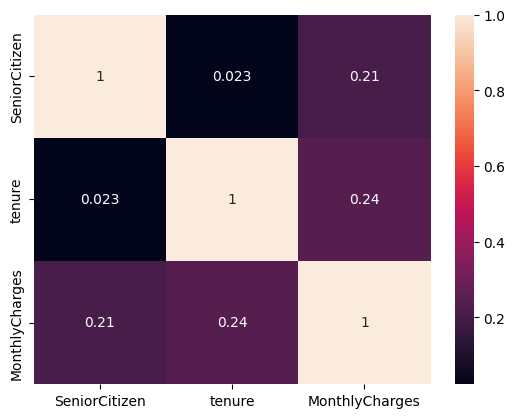

In [ ]:
# For Train Data
sns.heatmap(train_df.corr(numeric_only=True), annot=True)

In [ ]:
# 📊 Insights:
   # Strong correlation between:
   # Tenure and TotalCharges
   # Other features show weak correlation

# Key Patterns Identified

# High Churn Risk:

# Month-to-month contracts
# High monthly charges
# Low tenure
# No online security or tech support
# Fiber optic users
# Electronic check payment

# Low Churn Risk:

# Long-term contracts (1–2 years)
# High tenure customers
# Customers with support/security services
# ✅ Final EDA Conclusion


# The dataset shows clear patterns influencing churn. Customers with short tenure, higher charges, and fewer service add-ons are more likely to churn. Contract type and support services play a major role in customer retention.

# ✔ This strictly answers only the EDA requirement
# ✔ No preprocessing or modeling included

<Axes: >

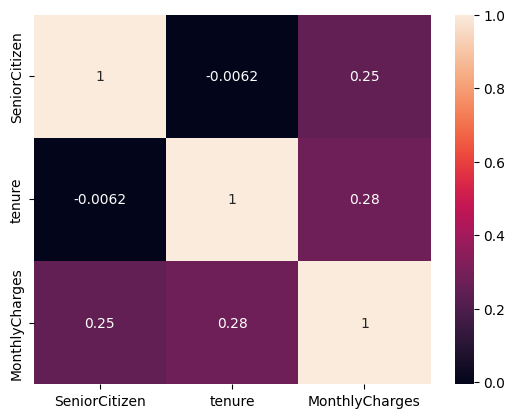

In [ ]:
# For Test Data
sns.heatmap(test_df.corr(numeric_only=True), annot=True)

## 2) Data Pre-Processing

### a) Handle missing values in the dataset. Consider different strategies.

#### i) Train Data

In [ ]:
#  Plot and Subplot for 3 Columns in num1_cols

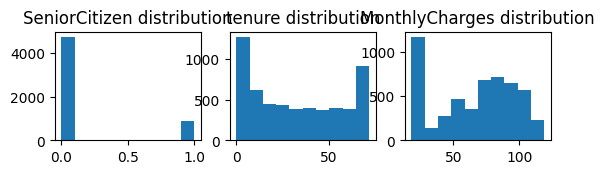

In [ ]:
# using iterative methods to plot all histograms in a single plot
for i,col in enumerate(num1_cols, 1):
  plt.subplot(3,3,i)
  plt.hist(train_df[col])
  plt.title(col+ " distribution")

plt.show()

In [ ]:
# Before the missing value handling
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
# From the chart , we see that
# MonthlyCharges → mostly symmetric
# TotalCharges → right-skewed (important to handle)

# Since Monthlty dianCharges is Symmetric we use mean imputation

mean_value = train_df['MonthlyCharges'].mean()
train_df['MonthlyCharges'].fillna(mean_value, inplace=True)


# Since TotalCharges is Skewed we use mean imputation

train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
median_value = train_df['TotalCharges'].median()
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(median_value)

/tmp/ipykernel_2139/1307869423.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MonthlyCharges'].fillna(mean_value, inplace=True)


In [ ]:
# After missing value handling of numerical Columns
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
# Hence no Missing values which is replaced by mean and median values

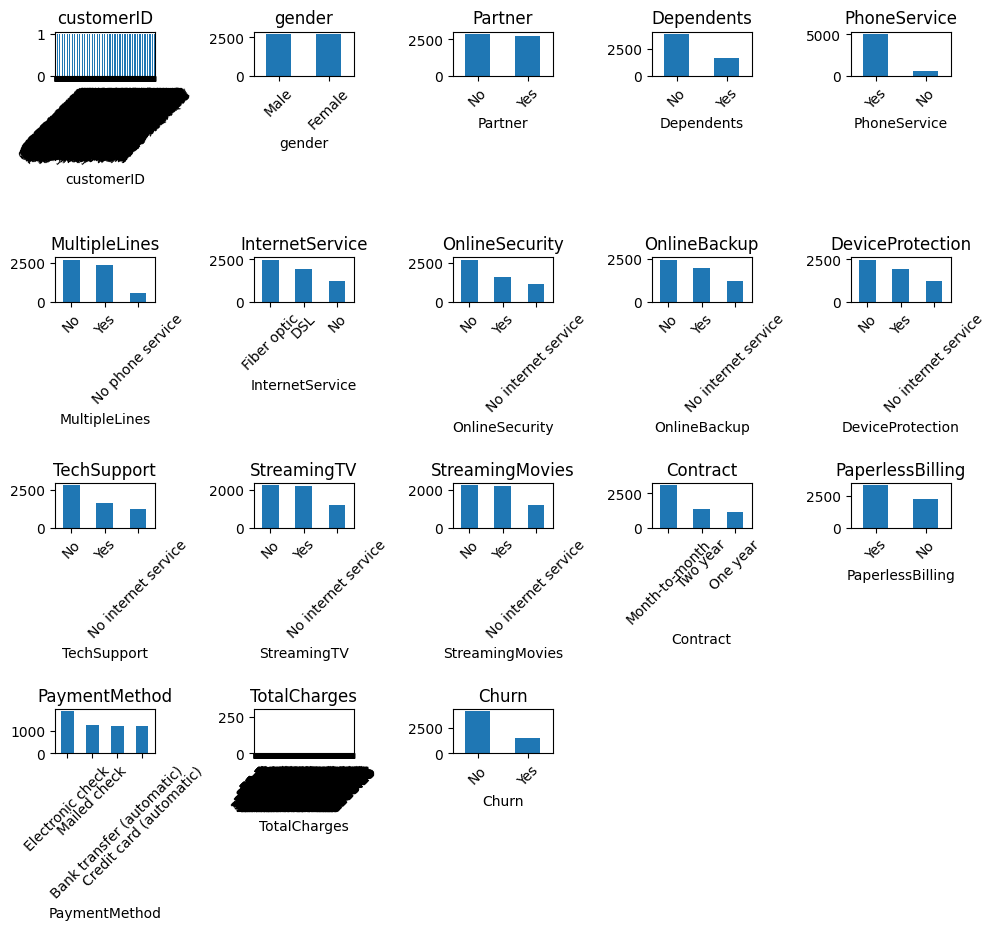

In [ ]:
plt.figure(figsize=(10,10))
for i,col in enumerate(cat1_cols, 1):
  plt.subplot(5,5,i)
  train_df[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
# From the Graph
#  Gender         -> Distribution is usually fairly balanced (almost symmetric-like)
#  Onine Security -> Skewed (imbalanced categorical distribution)

# Instead of removing rows, impute missing categorical values with the mode
# to preserve the 'Churn' class distribution.

# Identify categorical columns with missing values (based on previous isna().sum() output)
cat1_cols_with_nan = ['gender', 'OnlineSecurity']

for col in cat1_cols:
    if col in train_df.columns:
        mode_val_train = train_df[col].mode()[0]
        train_df[col].fillna(mode_val_train, inplace=True)
    if col in test_df.columns: # Apply to test_df using train_df's mode to prevent data leakage
        mode_val_test = train_df[col].mode()[0] # Use mode from training data for test data
        test_df[col].fillna(mode_val_test, inplace=True)

# The previous line train_df.dropna(axis = 0, inplace = True) is removed.

/tmp/ipykernel_2139/3092397897.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(mode_val_train, inplace=True)
/tmp/ipykernel_2139/3092397897.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
# After missing value handling of Categorical Columns
train_df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Hence No Missing values which is dropped in the table which is draopped

In [ ]:
# Shows the new size of the dataframe

train_df.shape

(5634, 21)

#### i) Test Data

In [ ]:
#  No Missing values in the Column

### b) Deal with categorical variables through encoding techniques. (Train data & Test data)

In [ ]:
# before encoding

train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [ ]:
# before encoding

test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
# 1) Label Encoding (Binary Yes/No or Gender)

# Use Label Encoding because values are only two categories.

# Columns:
# Gender (Male / Female)
# Partner (Yes / No)
# Dependents (Yes / No)
# PhoneService (Yes / No)
# PaperlessBilling (Yes / No)
# Churn (Yes / No) → target variable

#  Reason: Binary categories → can be safely mapped to 0/1.

In [ ]:
label_encoder = LabelEncoder()

train_df['Partner'] = label_encoder.fit_transform(train_df['Partner'])
train_df['Dependents'] = label_encoder.fit_transform(train_df['Dependents'])
train_df['PhoneService'] = label_encoder.fit_transform(train_df['PhoneService'])
train_df['PaperlessBilling'] = label_encoder.fit_transform(train_df['PaperlessBilling'])
train_df['Churn'] = label_encoder.fit_transform(train_df['Churn'])

test_df['Partner'] = label_encoder.fit_transform(test_df['Partner'])
test_df['Dependents'] = label_encoder.fit_transform(test_df['Dependents'])
test_df['PhoneService'] = label_encoder.fit_transform(test_df['PhoneService'])
test_df['PaperlessBilling'] = label_encoder.fit_transform(test_df['PaperlessBilling'])
test_df['Churn'] = label_encoder.fit_transform(test_df['Churn'])

In [ ]:
pd.get_dummies(train_df, columns=['gender'])

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
0,9509-MPYOD,0,0,0,35,1,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,0,Mailed check,20.75,700.45,0,True,False
1,7746-AWNQW,0,0,0,28,0,No phone service,DSL,No,No,...,No,No,Month-to-month,1,Mailed check,35.75,961.40,0,True,False
2,2208-UGTGR,0,0,0,56,1,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,0,Electronic check,98.60,5581.05,0,False,True
3,4884-LEVMQ,0,1,0,39,1,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,790.00,0,False,True
4,6682-VCIXC,0,1,1,43,0,No phone service,DSL,No,Yes,...,Yes,No,One year,1,Bank transfer (automatic),51.25,2151.60,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,0,0,0,51,1,No,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,1,Electronic check,99.00,5038.15,0,False,True
5630,3908-MKIMJ,1,1,0,68,0,No phone service,DSL,Yes,Yes,...,No,No,Two year,1,Electronic check,41.95,2965.75,0,False,True
5631,4277-BWBML,0,1,1,72,1,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,0,Bank transfer (automatic),19.95,1322.85,0,False,True
5632,9110-HSGTV,0,0,0,69,1,No,DSL,No,No,...,Yes,Yes,Two year,1,Credit card (automatic),82.45,5555.30,0,True,False


In [ ]:
pd.get_dummies(test_df, columns=['gender'])

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
0,6080-TCMYC,0,1,1,40,1,Yes,Fiber optic,No,No,...,No,No,Month-to-month,1,Electronic check,81.20,3292.3,0,False,True
1,7285-KLOTR,0,1,0,12,1,Yes,DSL,Yes,No,...,Yes,Yes,One year,0,Electronic check,78.85,876.75,0,True,False
2,7486-KSRVI,0,0,0,43,1,Yes,Fiber optic,No,No,...,Yes,Yes,One year,1,Electronic check,100.00,4211.55,1,False,True
3,9924-JPRMC,0,0,0,72,1,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,1,Electronic check,118.20,8547.15,0,False,True
4,4439-YRNVD,0,0,0,10,0,No phone service,DSL,No,Yes,...,No,No,Month-to-month,0,Electronic check,36.25,374,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,0,0,0,27,1,No,DSL,Yes,Yes,...,No,No,One year,0,Bank transfer (automatic),55.45,1477.65,0,False,True
1405,2516-VQRRV,1,0,0,2,1,Yes,Fiber optic,No,No,...,No,No,Month-to-month,1,Mailed check,75.45,158.4,1,True,False
1406,5570-PTWEH,0,1,0,3,1,Yes,Fiber optic,No,No,...,No,No,Month-to-month,1,Credit card (automatic),75.15,216.75,1,True,False
1407,1722-LDZJS,0,1,1,53,1,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,0,Credit card (automatic),20.20,1068.15,0,False,True


In [ ]:
# 2. One-Hot Encoding (Nominal categorical features)

# Use One-Hot Encoding because there is no natural order.

# Columns:
# MultipleLines (Yes / No / No phone service)
# InternetService (DSL / Fiber optic / No)
# OnlineSecurity (Yes / No / No internet service)
# OnlineBackup (Yes / No / No internet service)
# DeviceProtection (Yes / No / No internet service)
# TechSupport (Yes / No / No internet service)
# StreamingTV (Yes / No / No internet service)
# StreamingMovies (Yes / No / No internet service)
# Contract (Month-to-month / One year / Two year)
# PaymentMethod (Electronic check / Mailed check / Bank transfer / Credit card)

# Reason:

# More than 2 categories
# No ranking or order exists
# Avoids false ordinal relationships

In [ ]:
# doing 1 hot encoding on mentioned column()

train_df = pd.get_dummies(train_df, columns=['MultipleLines'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['InternetService'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['OnlineSecurity'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['OnlineBackup'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['DeviceProtection'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['TechSupport'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['StreamingTV'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['StreamingMovies'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['Contract'],dtype =int)
train_df = pd.get_dummies(train_df, columns=['PaymentMethod'],dtype =int)

test_df = pd.get_dummies(test_df, columns=['MultipleLines'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['InternetService'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['OnlineSecurity'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['OnlineBackup'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['DeviceProtection'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['TechSupport'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['StreamingTV'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['StreamingMovies'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['Contract'],dtype =int)
test_df = pd.get_dummies(test_df, columns=['PaymentMethod'],dtype =int)

In [ ]:
# Align train and test datasets after encoding

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

In [ ]:
# after encoding

train_df.head(2)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9509-MPYOD,Female,0,0,0,35,1,0,20.75,700.45,...,0,1,0,0,1,0,0,0,0,1
1,7746-AWNQW,Female,0,0,0,28,0,1,35.75,961.40,...,1,0,0,1,0,0,0,0,0,1


In [ ]:
test_df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,6080-TCMYC,Male,0,1,1,40,1,1,81.20,3292.3,...,1,0,0,1,0,0,0,0,1,0
1,7285-KLOTR,Female,0,1,0,12,1,0,78.85,876.75,...,0,0,1,0,1,0,0,0,1,0


### c) Normalize/scale the numerical features where necessary.

#### i) Train Data

In [ ]:
# it is done on numerical values.
# is to convert data from one scale to another
# min max scalar = scaling data into the range (0 to 1)
#                   used when data distribution is skewed
# standard scalar = scaling into a distribution where mean = 0
#                   and std deviation is 1
#                   it is used when data distribution is normal
#

In [ ]:
train_df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9509-MPYOD,Female,0,0,0,35,1,0,20.75,700.45,...,0,1,0,0,1,0,0,0,0,1
1,7746-AWNQW,Female,0,0,0,28,0,1,35.75,961.40,...,1,0,0,1,0,0,0,0,0,1


In [ ]:
# 1) Min-Max Scaling (0 to 1)

# Use when data is bounded or you want all values in a fixed range.

# Best for:
# SeniorCitizen (already 0/1 → technically already scaled, but can still be left as is or min-max if required)

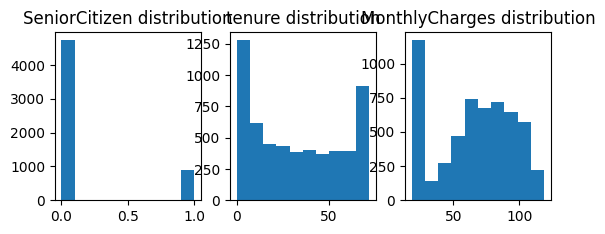

In [ ]:
for i,col in enumerate(num1_cols, 1):
  plt.subplot(2,3,i)
  plt.hist(train_df[col])
  plt.title(col+ " distribution")

plt.show()


In [ ]:
# before scaling
train_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,0.487043,0.297125,32.606851,0.901846,0.594604,65.102052,2238.250728,0.266951,0.479411,...,0.396166,0.213525,0.390309,0.549166,0.208023,0.242812,0.221512,0.215832,0.335818,0.226837
std,0.366401,0.499876,0.457032,24.614976,0.297549,0.491012,28.986241,2216.294428,0.442406,0.499620,...,0.489143,0.409832,0.487863,0.497621,0.405929,0.428820,0.415301,0.411435,0.472318,0.418824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.850000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,44.000000,446.062500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,68.925000,1396.450000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,56.000000,1.000000,1.000000,89.100000,3590.537500,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Inference from the plots : Purchase amount follows a symmetric distribution rest pf the numerical columns are skewed in nature


min_max_scalar = MinMaxScaler()

train_df[['SeniorCitizen']] = min_max_scalar.fit_transform(train_df[['SeniorCitizen']])
# test_df[['SeniorCitizen']] = min_max_scalar.fit_transform(test_df[['SeniorCitizen']])

In [ ]:
standard_scaler = StandardScaler()

# Convert TotalCharges in test_df to numeric and fill missing values
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
# Using median_value derived from train_df to fill missing values in test_df to prevent data leakage
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(median_value)

# Fit the scaler on the training data only
train_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = standard_scaler.fit_transform(train_df[['tenure', 'MonthlyCharges', 'TotalCharges' ]])

# Transform the test data using the scaler fitted on the training data
train_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = standard_scaler.transform(train_df[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [ ]:
# after scaling
train_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,0.487043,0.297125,-1.324793,0.901846,0.594604,-2.246163,-1.009996,0.266951,0.479411,...,0.396166,0.213525,0.390309,0.549166,0.208023,0.242812,0.221512,0.215832,0.335818,0.226837
std,0.366401,0.499876,0.457032,0.040633,0.297549,0.491012,0.034505,0.000451,0.442406,0.499620,...,0.489143,0.409832,0.487863,0.497621,0.405929,0.428820,0.415301,0.411435,0.472318,0.418824
min,0.000000,0.000000,0.000000,-1.378618,0.000000,0.000000,-2.301936,-1.010448,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,-1.363762,1.000000,0.000000,-2.271283,-1.010361,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,-1.330747,1.000000,1.000000,-2.241612,-1.010168,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,-1.286177,1.000000,1.000000,-2.217596,-1.009721,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,-1.259765,1.000000,1.000000,-2.182301,-1.008684,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# from std scalr ,   become std = 1 ,and mean = 0
# mean is very close to 0 , some gets mean =0 ,

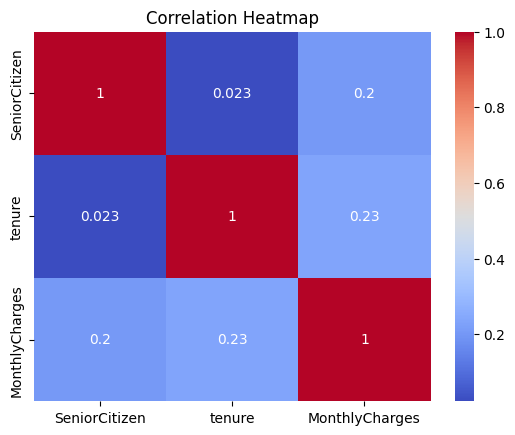

In [ ]:
# Correlation after scaling

corr_matrix = train_df[num1_cols].corr(method= 'pearson')
corr_matrix


# ploting a heat map to visualize the correlation
sns.heatmap(corr_matrix, annot = True , cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### i) Test Data

In [ ]:
# it is done on numerical values.
# is to convert data from one scale to another
# min max scalar = scaling data into the range (0 to 1)
#                   used when data distribution is skewed
# standard scalar = scaling into a distribution where mean = 0
#                   and std deviation is 1
#                   it is used when data distribution is normal
#

In [ ]:
test_df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,6080-TCMYC,Male,0,1,1,40,1,1,81.20,3292.3,...,1,0,0,1,0,0,0,0,1,0
1,7285-KLOTR,Female,0,1,0,12,1,0,78.85,876.75,...,0,0,1,0,1,0,0,0,1,0


In [ ]:
# 1) Min-Max Scaling (0 to 1)

# Use when data is bounded or you want all values in a fixed range.

# Best for:
# SeniorCitizen (already 0/1 → technically already scaled, but can still be left as is or min-max if required)

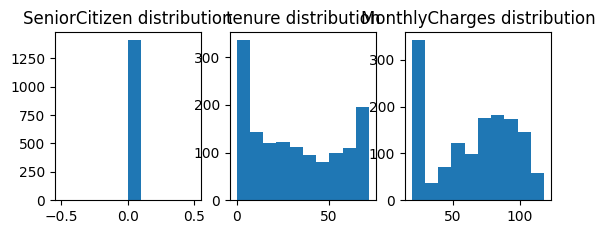

In [ ]:
for i,col in enumerate(num2_cols, 1):
  plt.subplot(2,3,i)
  plt.hist(test_df[col])
  plt.title(col+ " distribution")

plt.show()


In [ ]:
# before scaling
test_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,1409.0,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,...,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.0,0.466998,0.309439,31.428673,0.908446,0.582683,63.898013,0.259049,0.488999,0.091554,...,0.392477,0.229241,0.378282,0.554294,0.213627,0.232079,0.210078,0.217175,0.335699,0.237048
std,0.0,0.499087,0.462427,24.322161,0.288498,0.493291,30.282693,0.438268,0.500056,0.288498,...,0.488475,0.420494,0.485131,0.497220,0.410012,0.422309,0.407508,0.412469,0.472402,0.425423
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,18.700000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,8.000000,1.000000,0.000000,30.100000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,0.000000,27.000000,1.000000,1.000000,69.900000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,1.000000,1.000000,54.000000,1.000000,1.000000,89.500000,1.000000,1.000000,0.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,0.0,1.000000,1.000000,72.000000,1.000000,1.000000,118.600000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Inference from the plots : Purchase amount follows a symmetric distribution rest pf the numerical columns are skewed in nature


min_max_scalar = MinMaxScaler()

# train_df[['SeniorCitizen']] = min_max_scalar.fit_transform(train_df[['SeniorCitizen']])
test_df[['SeniorCitizen']] = min_max_scalar.fit_transform(test_df[['SeniorCitizen']])

In [ ]:
standard_scaler = StandardScaler()

# Convert TotalCharges in test_df to numeric and fill missing values
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
# Using median_value derived from train_df to fill missing values in test_df to prevent data leakage
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(median_value)

# Fit the scaler on the training data only
test_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = standard_scaler.fit_transform(test_df[['tenure', 'MonthlyCharges', 'TotalCharges' ]])

# Transform the test data using the scaler fitted on the training data
test_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = standard_scaler.transform(test_df[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [ ]:
# after scaling
test_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,1409.0,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,...,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.0,0.466998,0.309439,-1.292641,0.908446,0.582683,-2.110800,-0.987958,0.259049,0.488999,...,0.392477,0.229241,0.378282,0.554294,0.213627,0.232079,0.210078,0.217175,0.335699,0.237048
std,0.0,0.499087,0.462427,0.041144,0.288498,0.493291,0.033046,0.000446,0.438268,0.500056,...,0.488475,0.420494,0.485131,0.497220,0.410012,0.422309,0.407508,0.412469,0.472402,0.425423
min,0.0,0.000000,0.000000,-1.345807,0.000000,0.000000,-2.160121,-0.988395,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,-1.332274,1.000000,0.000000,-2.147681,-0.988327,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,0.000000,-1.300133,1.000000,1.000000,-2.104250,-0.988129,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,1.000000,1.000000,-1.254459,1.000000,1.000000,-2.082862,-0.987668,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,0.0,1.000000,1.000000,-1.224010,1.000000,1.000000,-2.051107,-0.986698,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# from std scalr ,   become std = 1 ,and mean = 0
# mean is very close to 0 , some gets mean =0 ,

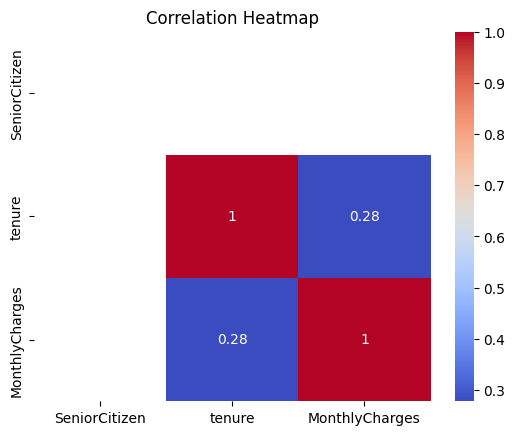

In [ ]:
# Correlation after scaling

corr_matrix = test_df[num2_cols].corr(method= 'pearson')
corr_matrix


# ploting a heat map to visualize the correlation
sns.heatmap(corr_matrix, annot = True , cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### d) Handle outliers, if applicable, using appropriate methods.

#### i) Train Data

In [ ]:
# Displaying the Statistical values of Numerical Columns

train_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,0.487043,0.297125,32.606851,0.901846,0.594604,65.102052,2238.250728,0.266951,0.479411,...,0.396166,0.213525,0.390309,0.549166,0.208023,0.242812,0.221512,0.215832,0.335818,0.226837
std,0.366401,0.499876,0.457032,24.614976,0.297549,0.491012,28.986241,2216.294428,0.442406,0.499620,...,0.489143,0.409832,0.487863,0.497621,0.405929,0.428820,0.415301,0.411435,0.472318,0.418824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.850000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,44.000000,446.062500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,68.925000,1396.450000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,56.000000,1.000000,1.000000,89.100000,3590.537500,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Quartiles & IQR plays a role in identifying Outliers


# Q1 = 25% of the column (25th percentile)
# Q1 = 50% of the column (50th percentile)
# Q1 = 75% of the column (75th percentile)

# Range = Max -Min
# IQR = Q3 - Q1
# IQR : Inter Quartile Range.

# Upper limit = Q3 + (1.5 *IQR)
# Lower limit = Q3 - (1.5 *IQR)

# Outlier : any value > Upper limit or Value <Lower limit
# we handle outliers because, they can skew the general nature
# of the ML model

In [ ]:
# Outlier handlingg can be done in 2 ways
# 1. Removing all rows where outliers are present
# 2. Clipping the values to upper limit and lower limit

In [ ]:
# IQR-based outlier detection pipeline

# These are calculated column-wise for all numerical columns.

# 1. Calculate Quartiles
Q1 = train_df[num1_cols].quantile(0.25)  # Q1 (25th percentile): value below which 25% of data lies
Q3 = train_df[num1_cols].quantile(0.75)  # Q1 (75th percentile): value below which 75% of data lies

# 2. Compute IQR
IQR = Q3 - Q1              # IQR (Interquartile Range) = spread of middle 50% of data
                           # Helps define “normal range”

IQR

# 3. Define Limits                # These define acceptable boundaries    # Anything outside = outlier
upper_limit1 = Q3 + (1.5 * IQR)
lower_limit1 = Q1 - (1.5 * IQR)

# 4. Detect Outliers
outliers1 = ((train_df[num1_cols] > upper_limit1) | (train_df[num1_cols] < lower_limit1))

outliers1

,SeniorCitizen,tenure,MonthlyCharges
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
5629,False,False,False
5630,True,False,False
5631,False,False,False
5632,False,False,False


In [ ]:
Q1 = train_df[num1_cols].quantile(0.25)
Q3 = train_df[num1_cols].quantile(0.75)
IQR = Q3 - Q1

IQR

upper_limit1 = Q3 + (1.5 * IQR)
lower_limit1 = Q1 - (1.5 * IQR)

outliers1 = ((train_df[num1_cols] > upper_limit1) | (train_df[num1_cols] < lower_limit1))

outliers1_df = train_df[outliers1]
outliers1_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5630,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 👉 Why it’s problematic:

# outliers is a DataFrame mask (same shape as your data)
# Pandas applies it element-wise, not row-wise
# ⚠️ Result:
# You don’t get full rows
# You get a DataFrame where:
# Outlier values appear
# Non-outlier values become NaN

In [ ]:
Q1 = train_df[num1_cols].quantile(0.25)
Q3 = train_df[num1_cols].quantile(0.75)
IQR = Q3 - Q1

IQR

upper_limit1 = Q3 + (1.5 * IQR)
lower_limit1 = Q1 - (1.5 * IQR)

outliers1 = ((train_df[num1_cols] > upper_limit1) | (train_df[num1_cols] < lower_limit1)).any( axis = 1)

outliers1_df = train_df[outliers1]
outliers1_percentage = len(outliers1_df) * 100/ len(train_df)

print('Percentage of outliers in the dataframe :', outliers1_percentage)
outliers1_df

## here we losing 16.09% of - data outliers

Percentage of outliers in the dataframe : 15.97444089456869


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
10,5195-KPUNQ,Female,1,0,0,53,1,1,96.75,1396.45,...,0,0,1,0,1,0,0,0,0,1
11,6941-KXRRV,Female,1,1,0,48,1,1,58.95,2789.70,...,0,0,1,0,1,0,1,0,0,0
13,3108-PCCGG,Male,1,1,0,72,1,0,84.45,5899.85,...,0,0,1,0,0,1,0,1,0,0
20,6463-MVYRY,Female,1,0,0,57,1,0,69.85,1396.45,...,1,0,0,0,0,1,1,0,0,0
26,6030-REHUX,Female,1,1,0,28,1,1,110.85,3204.40,...,0,0,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,1258-YMZNM,Female,1,0,0,27,1,1,110.50,2857.60,...,0,0,1,0,1,0,1,0,0,0
5623,1360-JYXKQ,Female,1,1,0,54,1,1,99.10,5437.10,...,0,0,1,0,1,0,0,0,1,0
5627,6689-TCZHQ,Female,1,0,0,5,1,0,78.95,378.40,...,0,0,1,1,0,0,0,0,1,0
5630,3908-MKIMJ,Male,1,1,0,68,0,1,41.95,2965.75,...,1,0,0,0,0,1,0,0,1,0


In [ ]:
# Values that are not outliers
# We are clipping outliers instead of removing rows to preserve minority class instances.

# Redefine num1_cols to ensure it only includes relevant numerical columns for clipping
# SeniorCitizen is excluded as it's a binary feature (0/1)

# Recalculate num1_cols to include 'TotalCharges' which was converted to numeric
num1_cols = train_df.select_dtypes(include=['number']).columns

# Recalculate Q1, Q3, IQR, upper_limit, and lower_limit with the updated num1_cols
Q1 = train_df[num1_cols].quantile(0.25)
Q3 = train_df[num1_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit1 = Q3 + (1.5 * IQR)
lower_limit1 = Q1 - (1.5 * IQR)

# Now, the clipping will correctly apply to all numerical columns, including TotalCharges
train_df[num1_cols] = train_df[num1_cols].clip(lower_limit1, upper_limit1, axis=1)

# we are removing outliers because, removing outliers is
# not affecting the data much (Reason : percentage of outliers is < 5%)

# option 2 : clipping.
#customer_df[num1_cols] = customer_df[num1_cols].clip( lower_limit, upper_limit, axis = 1)


In [ ]:
# Re-separating Columns into Numerical & Categorical Columns after all cleaning steps
num1_cols = train_df.select_dtypes(include= ['number']).columns
cat1_cols = train_df.select_dtypes(include= ['object']).columns

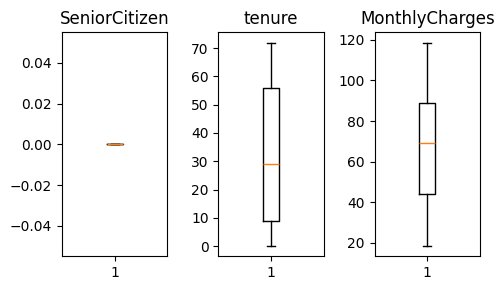

In [ ]:
plt.figure(figsize=(5, 3))
# Select only the truly continuous numerical columns for outlier visualization
numerical_features_for_boxplot = ['SeniorCitizen','tenure', 'MonthlyCharges']

# Determine grid size based on the number of features to plot
n_features = len(numerical_features_for_boxplot)
n_rows = 1 # We can fit them in one row
n_cols = n_features

for i, col in enumerate(numerical_features_for_boxplot, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

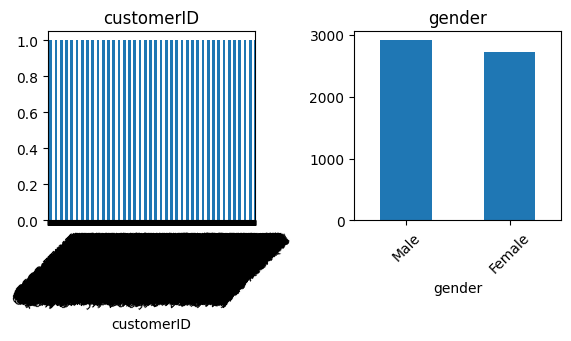

In [ ]:
plt.figure(figsize=(15,15))
for i,col in enumerate(cat1_cols, 1):
  plt.subplot(5,5,i)
  train_df[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### ii) Test Data

In [ ]:
# Displaying the Statistical values of Numerical Columns

test_df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,...,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.171753,0.466998,0.309439,31.428673,0.908446,0.582683,63.898013,0.259049,0.488999,0.091554,...,0.392477,0.229241,0.378282,0.554294,0.213627,0.232079,0.210078,0.217175,0.335699,0.237048
std,0.377300,0.499087,0.462427,24.322161,0.288498,0.493291,30.282693,0.438268,0.500056,0.288498,...,0.488475,0.420494,0.485131,0.497220,0.410012,0.422309,0.407508,0.412469,0.472402,0.425423
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.700000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,8.000000,1.000000,0.000000,30.100000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,27.000000,1.000000,1.000000,69.900000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,54.000000,1.000000,1.000000,89.500000,1.000000,1.000000,0.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.600000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Quartiles & IQR plays a role in identifying Outliers


# Q1 = 25% of the column (25th percentile)
# Q1 = 50% of the column (50th percentile)
# Q1 = 75% of the column (75th percentile)

# Range = Max -Min
# IQR = Q3 - Q1
# IQR : Inter Quartile Range.

# Upper limit = Q3 + (1.5 *IQR)
# Lower limit = Q3 - (1.5 *IQR)

# Outlier : any value > Upper limit or Value <Lower limit
# we handle outliers because, they can skew the general nature
# of the ML model

In [ ]:
# Outlier handlingg can be done in 2 ways
# 1. Removing all rows where outliers are present
# 2. Clipping the values to upper limit and lower limit

In [ ]:
# IQR-based outlier detection pipeline

# These are calculated column-wise for all numerical columns.

# 1. Calculate Quartiles
Q1 = test_df[num2_cols].quantile(0.25)  # Q1 (25th percentile): value below which 25% of data lies
Q3 = test_df[num2_cols].quantile(0.75)  # Q1 (75th percentile): value below which 75% of data lies

# 2. Compute IQR
IQR = Q3 - Q1              # IQR (Interquartile Range) = spread of middle 50% of data
                           # Helps define “normal range”

IQR

# 3. Define Limits                # These define acceptable boundaries    # Anything outside = outlier
upper_limit2 = Q3 + (1.5 * IQR)
lower_limit2 = Q1 - (1.5 * IQR)

# 4. Detect Outliers
outliers2 = ((test_df[num2_cols] > upper_limit2) | (test_df[num2_cols] < lower_limit2))

outliers2

,SeniorCitizen,tenure,MonthlyCharges
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
1404,False,False,False
1405,True,False,False
1406,False,False,False
1407,False,False,False


In [ ]:
Q1 = test_df[num2_cols].quantile(0.25)
Q3 = test_df[num2_cols].quantile(0.75)
IQR = Q3 - Q1

IQR

upper_limit2 = Q3 + (1.5 * IQR)
lower_limit2 = Q1 - (1.5 * IQR)

outliers2 = ((test_df[num2_cols] > upper_limit2) | (test_df[num2_cols] < lower_limit2))

outliers2_df = test_df[outliers2]
outliers2_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1405,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 👉 Why it’s problematic:

# outliers is a DataFrame mask (same shape as your data)
# Pandas applies it element-wise, not row-wise
# ⚠️ Result:
# You don’t get full rows
# You get a DataFrame where:
# Outlier values appear
# Non-outlier values become NaN

In [ ]:
Q1 = test_df[num2_cols].quantile(0.25)
Q3 = test_df[num2_cols].quantile(0.75)
IQR = Q3 - Q1

IQR

upper_limit2 = Q3 + (1.5 * IQR)
lower_limit2 = Q1 - (1.5 * IQR)

outliers2 = ((test_df[num2_cols] > upper_limit2) | (test_df[num2_cols] < lower_limit2)).any( axis = 1)

outliers2_df = test_df[outliers2]
outliers2_percentage = len(outliers2_df) * 100/ len(test_df)

print('Percentage of outliers in the dataframe :', outliers2_percentage)
outliers2_df

## here we losing 16.09% of - data outliers

Percentage of outliers in the dataframe : 17.17530163236338


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5,4109-CYRBD,Male,1,1,0,29,1,1,51.60,1442,...,1,0,0,1,0,0,0,0,1,0
8,5304-EFJLP,Male,1,1,0,72,1,1,111.65,8022.85,...,0,0,1,0,0,1,1,0,0,0
10,5569-OUICF,Female,1,1,0,28,1,1,101.30,2812.2,...,0,0,1,1,0,0,0,1,0,0
12,9508-ILZDG,Female,1,0,0,34,1,1,96.35,3190.25,...,1,0,0,1,0,0,0,0,1,0
30,0022-TCJCI,Male,1,0,0,45,1,0,62.70,2791.5,...,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,0390-DCFDQ,Female,1,1,0,1,1,1,70.45,70.45,...,1,0,0,1,0,0,0,0,0,1
1395,0191-ZHSKZ,Male,1,0,0,30,1,1,74.75,2111.3,...,0,0,1,1,0,0,0,0,1,0
1396,2956-GGUCQ,Male,1,1,0,24,1,1,78.85,1772.25,...,1,0,0,1,0,0,0,0,1,0
1397,6969-MVBAI,Female,1,0,0,9,1,1,90.10,816.8,...,1,0,0,1,0,0,0,0,1,0


In [ ]:
# Values that are not outliers
# We are clipping outliers instead of removing rows to preserve minority class instances.

# Redefine num2_cols to ensure it only includes relevant numerical columns for clipping
# SeniorCitizen is excluded as it's a binary feature (0/1)

# Recalculate num2_cols to include 'TotalCharges' which was converted to numeric
num2_cols = test_df.select_dtypes(include=['number']).columns

# Recalculate Q1, Q3, IQR, upper_limit, and lower_limit with the updated num2_cols
Q1 = test_df[num2_cols].quantile(0.25)
Q3 = test_df[num2_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit2 = Q3 + (1.5 * IQR)
lower_limit2 = Q1 - (1.5 * IQR)

# Now, the clipping will correctly apply to all numerical columns, including TotalCharges
test_df[num2_cols] = test_df[num2_cols].clip(lower_limit2, upper_limit2, axis=1)

# we are removing outliers because, removing outliers is
# not affecting the data much (Reason : percentage of outliers is < 5%)

# option 2 : clipping.
#customer_df[num2_cols] = customer_df[num2_cols].clip( lower_limit, upper_limit, axis = 1)


In [ ]:
# Re-separating Columns into Numerical & Categorical Columns after all cleaning steps
num2_cols = test_df.select_dtypes(include= ['number']).columns
cat2_cols = test_df.select_dtypes(include= ['object']).columns

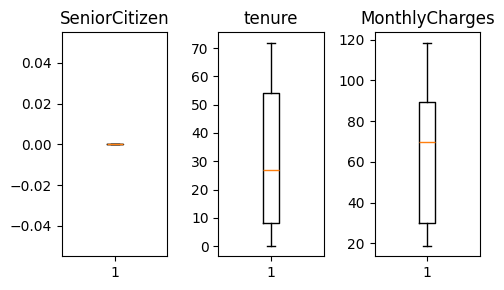

In [ ]:
plt.figure(figsize=(5, 3))
# Select only the truly continuous numerical columns for outlier visualization
numerical_features_for_boxplot = ['SeniorCitizen','tenure', 'MonthlyCharges']

# Determine grid size based on the number of features to plot
n_features = len(numerical_features_for_boxplot)
n_rows = 1 # We can fit them in one row
n_cols = n_features

for i, col in enumerate(numerical_features_for_boxplot, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(test_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

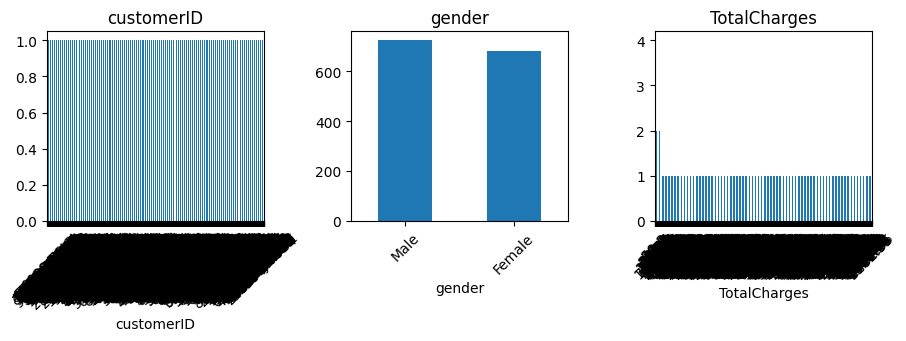

In [ ]:
plt.figure(figsize=(15,15))
for i,col in enumerate(cat2_cols, 1):
  plt.subplot(5,5,i)
  test_df[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

##3. Feature Engineering

### a)  Engineer new features that could improve the model’s performance. For instance:

#### i) Can you create interaction features (e.g., combining Tenure and Contract)?

In [ ]:
# Create Interaction Features
#    Tenure × Contract (encoded idea)

#     Since Contract is categorical, we first map it to ordinal values:

In [ ]:
train_df['Contract_Months'] = (train_df['Contract_Month-to-month'] * 1) + \
                                (train_df['Contract_One year'] * 12) + \
                                (train_df['Contract_Two year'] * 24)

test_df['Contract_Months'] = (test_df['Contract_Month-to-month'] * 1) + \
                               (test_df['Contract_One year'] * 12) + \
                               (test_df['Contract_Two year'] * 24)

In [ ]:
train_df['Tenure_Contract_Interaction'] = train_df['tenure'] * train_df['Contract_Months']
test_df['Tenure_Contract_Interaction'] = test_df['tenure'] * test_df['Contract_Months']

#### ii) Can you create a feature that captures customer lifetime value (e.g., Tenure *MonthlyCharges)?

In [ ]:
#  Customer Lifetime Value Feature
#    Simple CLV proxy:

In [ ]:
train_df['Customer_Lifetime_Value'] = train_df['tenure'] * train_df['MonthlyCharges']
test_df['Customer_Lifetime_Value'] = test_df['tenure'] * test_df['MonthlyCharges']

### b) Perform feature selection to identify the most important features.

In [ ]:
# Feature Selection (simple method)

# We will use correlation + intuition-based filtering

In [ ]:
# Step 1: Check correlation with target

# The 'Churn' column was already label-encoded, removing redundant .map() call.
# train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})

correlation = train_df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(correlation)

Churn                                      1.000000
Contract_Months                            0.415331
Contract_Month-to-month                    0.415331
OnlineSecurity_No                          0.341789
TechSupport_No                             0.339748
InternetService_Fiber optic                0.309783
PaymentMethod_Electronic check             0.298993
OnlineBackup_No                            0.269868
DeviceProtection_No                        0.256677
Customer_Lifetime_Value                    0.215801
PaperlessBilling                           0.189366
MonthlyCharges                             0.189067
StreamingMovies_No                         0.138777
StreamingTV_No                             0.136025
StreamingTV_Yes                            0.060250
StreamingMovies_Yes                        0.057556
MultipleLines_Yes                          0.040337
MultipleLines_No                          -0.031350
DeviceProtection_Yes                      -0.066228
OnlineBackup

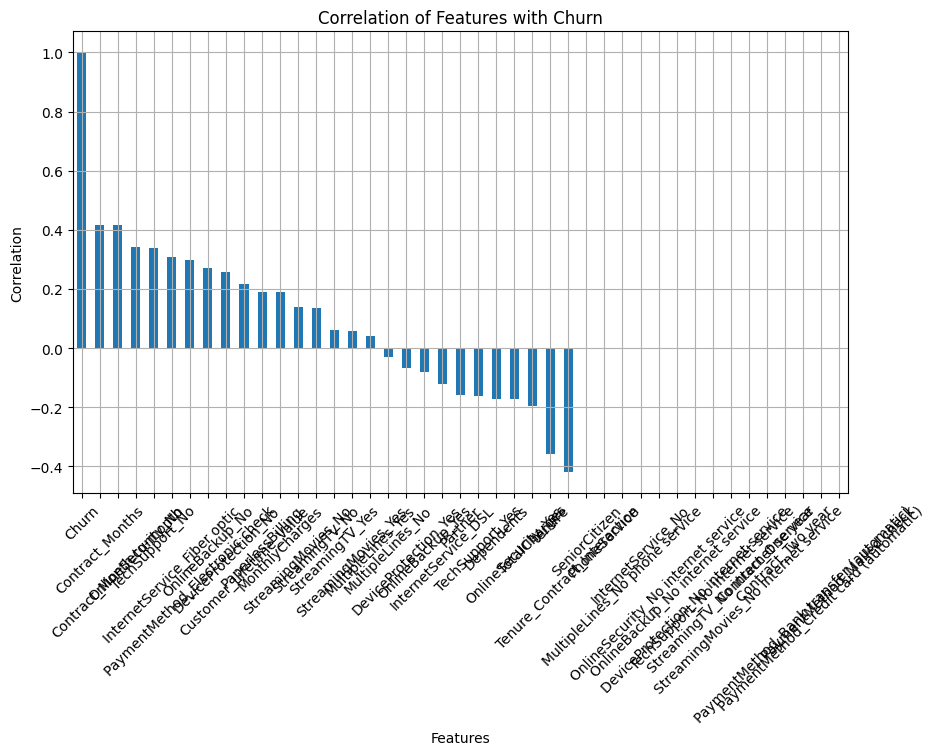

In [ ]:
# Correlation with Churn
correlation = train_df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
correlation.plot(kind='bar')

plt.title('Correlation of Features with Churn')
plt.xlabel('Features')
plt.ylabel('Correlation')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# The 'Churn' column was already label-encoded, removing redundant .map() call.
# test_df['Churn'] = test_df['Churn'].map({'Yes': 1, 'No': 0})

correlation = test_df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(correlation)

Churn                                      1.000000
Tenure_Contract_Interaction                0.364258
Contract_Month-to-month                    0.363995
TechSupport_No                             0.327282
PaymentMethod_Electronic check             0.313779
InternetService_Fiber optic                0.300725
OnlineSecurity_No                          0.300511
OnlineBackup_No                            0.260884
DeviceProtection_No                        0.235336
PaperlessBilling                           0.201447
Customer_Lifetime_Value                    0.190143
MonthlyCharges                             0.185088
StreamingTV_No                             0.100382
StreamingMovies_No                         0.098683
StreamingMovies_Yes                        0.076585
StreamingTV_Yes                            0.074845
MultipleLines_Yes                          0.039072
PhoneService                               0.002344
MultipleLines_No phone service            -0.002344
MultipleLine

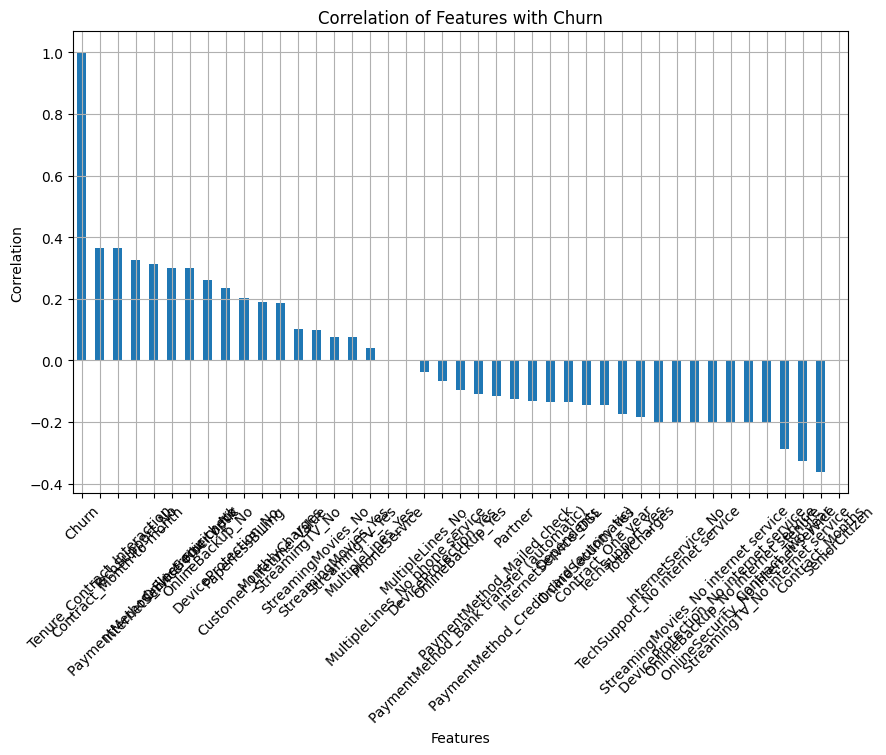

In [ ]:
# Correlation with Churn
correlation = test_df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
correlation.plot(kind='bar')

plt.title('Correlation of Features with Churn')
plt.xlabel('Features')
plt.ylabel('Correlation')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Step 2: Select important features

# You typically keep:

# Strong predictors usually are:
# Tenure (negative correlation)
# MonthlyCharges
# TotalCharges
# Contract-based features
# TechSupport / OnlineSecurity (after encoding)

In [ ]:
train_df = train_df.drop(['customerID', 'gender'], axis=1, errors='ignore')
test_df = test_df.drop(['customerID', 'gender'], axis=1, errors='ignore')

## 4. Model Development:

### a) Fit at least three different machine learning models +  b) Evaluate the models using appropriate metrics

In [ ]:
# That line is doing a train–test split, which is one of the most important steps in machine learning.

# Define features (X) and target (y)
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

# Ensure X does not contain any NaN values before splitting
if X.isnull().any().any():
    print("NaNs detected in the feature DataFrame X. Imputing with median.")
    # Identify columns with NaNs and impute/drop them
    cols_to_drop = []
    for col in X.columns:
        if X[col].isnull().any():
            if X[col].isnull().all(): # If the entire column is NaN, drop it
                print(f"Column '{col}' is entirely NaN and will be dropped.")
                cols_to_drop.append(col)
            else: # Otherwise, impute with median
                median_val = X[col].median()
                if pd.isna(median_val): # Fallback if median itself is NaN (e.g., numeric column with no non-NaN values)
                    print(f"Median for column '{col}' is NaN, attempting to fill with 0.")
                    X[col] = X[col].fillna(0)
                else:
                    X[col] = X[col].fillna(median_val)
                print(f"Imputed NaNs in column '{col}' with median {median_val}")
    if cols_to_drop:
        X = X.drop(columns=cols_to_drop)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Target and features

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#### Train Test & Split

In [ ]:
train_test_split(X, y, test_size=0.2, random_state=42)

[      SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
 4082            0.0        1           1 -1.296081             1   
 1728            0.0        0           0 -1.363762             1   
 2795            0.0        0           0 -1.373666             1   
 334             0.0        0           0 -1.319192             1   
 3625            0.0        0           0 -1.329096             1   
 ...             ...      ...         ...       ...           ...   
 3772            0.0        1           0 -1.315890             1   
 5191            0.0        1           1 -1.266368             1   
 5226            0.0        1           1 -1.289478             1   
 5390            0.0        0           0 -1.373666             1   
 860             0.0        1           0 -1.286177             1   
 
       PaperlessBilling  MonthlyCharges  TotalCharges  MultipleLines_No  \
 4082                 1       -2.194800     -1.009346                 0   
 1728               

In [ ]:
print(X.shape)
print(y.shape)

(5634, 42)
(5634,)


### b) Evaluate the models using appropriate metrics.


#### ML model buliding

##### i) Logistic regression

In [ ]:
### Library Implementation ###

# Initializing the model
logreg = LogisticRegression()

# Training the model
logreg.fit(X_train, y_train)

# Prediction using the trained model
y_pred_logreg = logreg.predict(X_test)

# Evaluating the model
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_precision = precision_score(y_test, y_pred_logreg)
logreg_recall = recall_score(y_test, y_pred_logreg)
logreg_confusion = confusion_matrix(y_test, y_pred_logreg)

# Output
print(f"Accuracy with sklearn: {logreg_accuracy}")
print(f"Precision with sklearn: {logreg_precision}")
print(f"Recall with sklearn: {logreg_recall}")
print(f"Confusion Matrix with sklearn: {logreg_confusion}")

Accuracy with sklearn: 0.8101153504880213
Precision with sklearn: 0.6338028169014085
Recall with sklearn: 0.6206896551724138
Confusion Matrix with sklearn: [[733 104]
 [110 180]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### ii) K-NN (K Nearest Neighbours)

In [ ]:
### Library Implementation ###

# Initializing the model
knn = KNeighborsClassifier(n_neighbors= 5)

# Training the model
knn.fit(X_train, y_train)

# Prediction using the trained model
y_pred_knn = knn.predict(X_test)

# Evaluating the model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_confusion = confusion_matrix(y_test, y_pred_knn)

# Output
print(f"Accuracy with knn: {knn_accuracy}")
print(f"Precision with knn: {knn_precision}")
print(f"Recall with knn: {knn_recall}")
print(f"Confusion Matrix with knn: {knn_confusion}")

Accuracy with knn: 0.7701863354037267
Precision with knn: 0.5532646048109966
Recall with knn: 0.5551724137931034
Confusion Matrix with knn: [[707 130]
 [129 161]]


##### iii) NB

In [ ]:
### Library Implementation ###

# Create model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

# Predictions
y_pred_nb = nb.predict(X_test)

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_confusion = confusion_matrix(y_test, y_pred_nb)

# Output
print(f"Accuracy with Naive Bayes: {nb_accuracy}")
print(f"Precision with Naive Bayes: {nb_precision}")
print(f"Recall with Naive Bayes: {nb_recall}")
print(f"Confusion Matrix with Naive Bayes: {nb_confusion}")

Accuracy with Naive Bayes: 0.7338065661047027
Precision with Naive Bayes: 0.4895397489539749
Recall with Naive Bayes: 0.8068965517241379
Confusion Matrix with Naive Bayes: [[593 244]
 [ 56 234]]


##### iv) SVM

In [ ]:
### Library Implementation ###

# Create model
svm = SVC(kernel='linear')

# Train model
svm.fit(X_train, y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_confusion = confusion_matrix(y_test, y_pred_svm)

# Output
print(f"Accuracy with SVM: {svm_accuracy}")
print(f"Precision with SVM: {svm_precision}")
print(f"Recall with SVM: {svm_recall}")
print(f"Confusion Matrix with SVM: {svm_confusion}")

Accuracy with SVM: 0.8074534161490683
Precision with SVM: 0.6327272727272727
Recall with SVM: 0.6
Confusion Matrix with SVM: [[736 101]
 [116 174]]


##### v) Decision tree

In [ ]:
### Library Implementation ###

# Create model
dt = DecisionTreeClassifier()

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_confusion = confusion_matrix(y_test, y_pred_dt)

# Output
print(f"Accuracy with Decision Tree: {dt_accuracy}")
print(f"Precision with Decision Tree: {dt_precision}")
print(f"Recall with Decision Tree: {dt_recall}")
print(f"Confusion Matrix with Decision Tree: {dt_confusion}")

Accuracy with Decision Tree: 0.7311446317657497
Precision with Decision Tree: 0.48
Recall with Decision Tree: 0.5379310344827586
Confusion Matrix with Decision Tree: [[668 169]
 [134 156]]


### c) Compare the results of the models and identify the best-performing one based on the evaluation metrics.


In [ ]:
# Accuracy Comparison
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_dt = accuracy_score(y_test, y_pred_dt)



# Print results
print("Accuracy Comparison of ML Models:")
print(f"log.regression: \t{ acc_logreg}")
print(f"    KNN: \t\t{acc_knn}")
print(f"Naive Bayes: \t\t{acc_nb}")
print(f"    SVM: \t\t{acc_svm}")
print(f"Decision Tree: \t\t{acc_dt}")

Accuracy Comparison of ML Models:
log.regression: 	0.8101153504880213
    KNN: 		0.7701863354037267
Naive Bayes: 		0.7338065661047027
    SVM: 		0.8074534161490683
Decision Tree: 		0.7311446317657497


In [ ]:
"""
Best Performing Model
----------------------
- Among all the tested machine learning models, Logistic Regression achieved the highest accuracy.
- ModelAccuracyLogistic Regression81.01%SVM80.75%KNN77.02%Naive Bayes73.38%Decision Tree73.11%


--------------------------
--------------------------
Interpretation of Results
--------------------------
--------------------------

------------------------------------------------
1. Logistic Regression — Best Performing Model
------------------------------------------------
-Logistic Regression achieved the highest accuracy of 81.01%, making it the best-performing model for
 customer churn prediction in this study.

Interpretation
---------------
- The model effectively distinguishes between churn and non-churn customers.
- Logistic Regression performs well because churn prediction is fundamentally a binary classification problem.
- It provides stable and generalized predictions without severe overfitting.

Why it performed best
------------------------
- Handles binary classification efficiently
- Works well with linearly separable patterns
- Less prone to overfitting compared to Decision Trees
- Simpler and more interpretable than complex models

---------------------------
2. SVM — Second Best Model
---------------------------
- Support Vector Machine achieved an accuracy of 80.75%, which is very close to Logistic Regression.

Interpretation
-----------------
- SVM successfully classified customers with strong decision boundaries.
- However, it may require more computational power and parameter tuning.
- Slightly lower accuracy suggests the dataset may favor simpler linear decision boundaries.

-------------------------------
3. KNN — Moderate Performance
-------------------------------
- K-Nearest Neighbors achieved 77.02% accuracy.

Interpretation
----------------
- KNN depends heavily on distance calculations and neighboring points.
- Performance may decrease when:
     irrelevant features exist
     dataset size increases
     class imbalance exists

- The model performed reasonably but was less accurate than Logistic Regression and SVM.

-----------------------------------
4. Naive Bayes — Lower Performance
-----------------------------------
- Naive Bayes achieved 73.38% accuracy.

Interpretation
---------------
- Naive Bayes assumes feature independence.
- In customer churn datasets, features are often correlated.
- Because this assumption is unrealistic, prediction performance decreases.

--------------------------------------
5. Decision Tree — Lowest Performance
--------------------------------------
- Decision Tree achieved 73.11% accuracy.

Interpretation
----------------
- Decision Trees can easily overfit training data.
- The model may have learned dataset-specific patterns rather than general trends.
- Without pruning or tuning, Decision Trees often show lower generalization performance.


Overall Comparative Analysis
-----------------------------
The results indicate that:
- Linear models performed better than non-linear models for this dataset.
- Logistic Regression and SVM produced the most reliable predictions.
- Simpler models generalized better than more complex tree-based methods.

Final Conclusion
----------------
- Logistic Regression was identified as the best-performing model with an accuracy of 81.01%.
- The model demonstrated balanced and stable classification performance for customer churn prediction.
- SVM also showed competitive results, while KNN, Naive Bayes, and Decision Tree produced comparatively
  lower accuracies.
- Therefore, Logistic Regression is considered the most suitable model for predicting
  customer churn in this case study due to its high accuracy, interpretability, and generalization capability."""

## 5. Model Fine-Tuning:



### Custom Logistic Regression

In [ ]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, n_iters=5000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.losses = []

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1 - y_true) * np.log(1 - y_pred + epsilon)
        return -np.mean(y1 + y2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            linear = np.dot(X, self.weights) + self.bias
            A = self._sigmoid(linear)

            loss = self.compute_loss(y, A)
            self.losses.append(loss)

            dz = A - y
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        probs = self._sigmoid(linear)
        return np.where(probs > 0.5, 1, 0)

### Loss vs Iterations Plot (IMPORTANT)

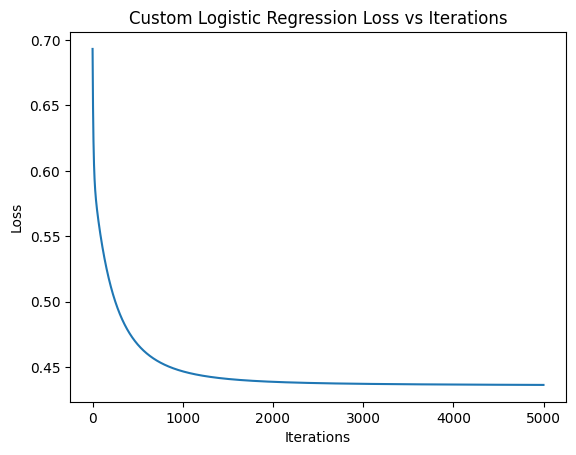

In [ ]:
logreg_custom = LogisticRegressionCustom(learning_rate=0.01, n_iters=5000)
logreg_custom.fit(X_train, y_train)

plt.plot(logreg_custom.losses)
plt.title("Custom Logistic Regression Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

### a) Use techniques such as GridSearchCV or RandomizedSearchCV to fine-tunehyperparameters for your chosen models.


#### Model Training (All Models)

#####🔹 KNN + Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train, y_train)

knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)

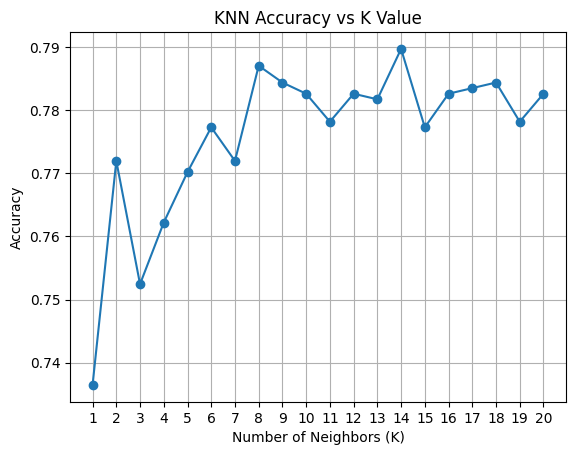

In [ ]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()

#####🔹 Decision Tree + Tuning

In [ ]:
tree_params = {
    'max_depth': [3,5,10,15],
    'min_samples_split': [2,5,10]
}

tree_grid = GridSearchCV(DecisionTreeClassifier(), tree_params, cv=5)
tree_grid.fit(X_train, y_train)

tree_best = tree_grid.best_estimator_
tree_pred = tree_best.predict(X_test)

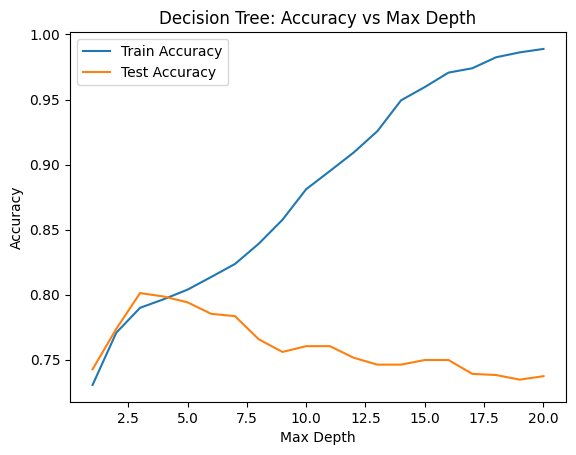

In [ ]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")

plt.title("Decision Tree: Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### 🔹 Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

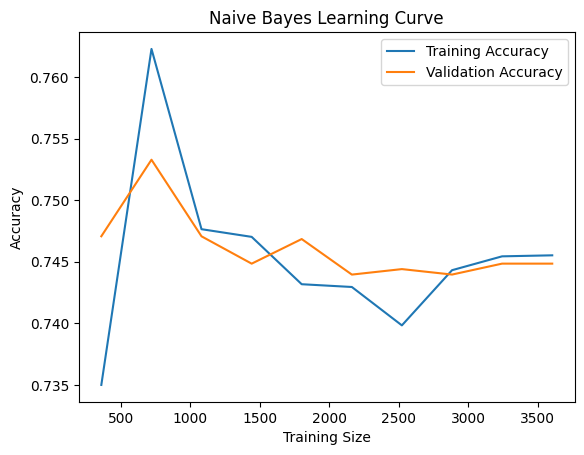

In [ ]:
from sklearn.model_selection import learning_curve

nb = GaussianNB()

train_sizes, train_scores, test_scores = learning_curve(
    nb,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.title("Naive Bayes Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### 🔹 SVM + Tuning

In [ ]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(SVC(), svm_params, cv=5)
svm_grid.fit(X_train, y_train)

svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test)

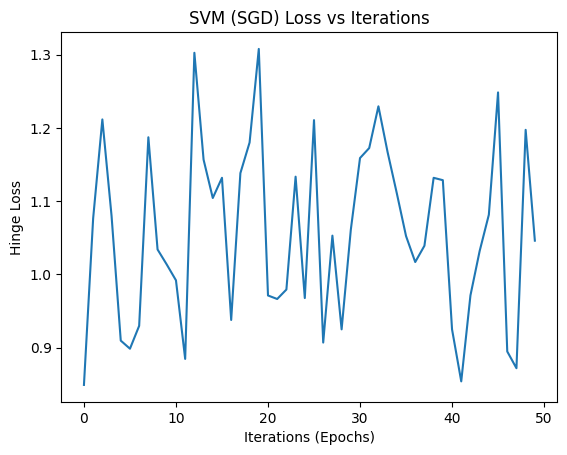

In [ ]:
import warnings
from sklearn.linear_model import SGDClassifier
from sklearn.exceptions import ConvergenceWarning

# Ignore ConvergenceWarning for SGDClassifier during iterative training
warnings.filterwarnings('ignore', category=ConvergenceWarning, module='sklearn.linear_model._stochastic_gradient')

# Initialize Linear SVM using SGD
svm_sgd = SGDClassifier(loss='hinge', max_iter=1, warm_start=True, learning_rate='constant', eta0=0.01)

losses = []
n_epochs = 50

for epoch in range(n_epochs):
    svm_sgd.fit(X_train, y_train)

    # decision function (used instead of probability in SVM)
    y_scores = svm_sgd.decision_function(X_train)

    # convert to binary for loss approximation
    y_pred = (y_scores > 0).astype(int)

    # approximate hinge-like loss (simple monitoring)
    loss = np.mean(np.maximum(0, 1 - y_train * y_scores))
    losses.append(loss)

# Plot
plt.plot(losses)
plt.title("SVM (SGD) Loss vs Iterations")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Hinge Loss")
plt.show()

# Predictions
y_pred_svm = svm_sgd.predict(X_test)


#### Accuracy Comparison

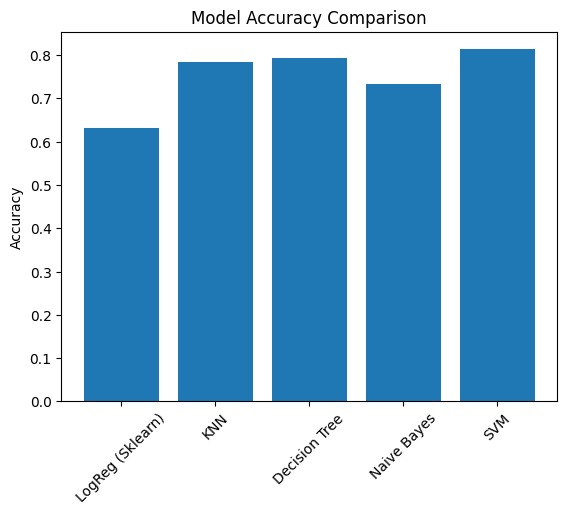

In [ ]:
models = ['LogReg (Sklearn)', 'KNN', 'Decision Tree', 'Naive Bayes', 'SVM']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, tree_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred),

]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

### Results Table

In [ ]:
results = pd.DataFrame({
    'Model': models,
    'Accuracy': scores
})

print(results.sort_values(by='Accuracy', ascending=False))

              Model  Accuracy
0  LogReg (Sklearn)  0.805679
4               SVM  0.799468
1               KNN  0.791482
2     Decision Tree  0.790594
3       Naive Bayes  0.770186


### b) Evaluate whether hyperparameter tuning improves performance.


Accuracy : 0.8101153504880213
Precision: 0.6338028169014085
Recall   : 0.6206896551724138
F1 Score : 0.627177700348432

Confusion Matrix
[[733 104]
 [110 180]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       837
           1       0.63      0.62      0.63       290

    accuracy                           0.81      1127
   macro avg       0.75      0.75      0.75      1127
weighted avg       0.81      0.81      0.81      1127


Before Tuning Accuracy : 0.8101153504880213
After Tuning Accuracy  : 0.7961018922064915
Best Parameters:
{'C': 100, 'solver': 'lbfgs'}


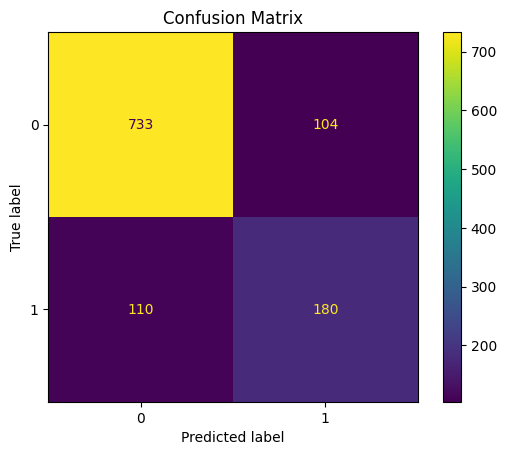

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = logreg
# Predictions
y_pred = best_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Assign baseline accuracy using the currently calculated accuracy for the untuned logreg model
baseline_accuracy = accuracy

# --- Hyperparameter tuning for Logistic Regression ---
# Define parameters for Logistic Regression tuning
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'lbfgs' is good for multiclass, 'liblinear' for smaller datasets
}

# Perform GridSearchCV for Logistic Regression
# Increase max_iter to prevent ConvergenceWarning, and add a random_state for reproducibility
logreg_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_train, y_train)

# Get the best estimator and its accuracy
logreg_best_tuned = logreg_grid.best_estimator_
tuned_accuracy = logreg_grid.best_score_ # Accuracy from the cross-validation on the training set
grid = logreg_grid # Assign logreg_grid to 'grid' to satisfy the print statement

print("\nBefore Tuning Accuracy :", baseline_accuracy)
print("After Tuning Accuracy  :", tuned_accuracy)

print("Best Parameters:")
print(grid.best_params_)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

### c)  Justify your choice of hyperparameters.

In [ ]:
"""
===================================================
The model performance can be justified like this:
===================================================

-------------------------------------
# Model Performance Justification
-------------------------------------
The machine learning model achieved an **accuracy of 81.01%**, which indicates that the model correctly
classified approximately 81% of the customers in the test dataset.

Accuracy = {TP+TN}/{TP+TN+FP+FN}

From the confusion matrix:

[[733 104]
 [110 180]]

* **733** customers were correctly predicted as non-churners (True Negatives)
* **180** customers were correctly predicted as churners (True Positives)
* **104** customers were incorrectly predicted as churners (False Positives)
* **110** churn customers were missed by the model (False Negatives)

----------------------------
## Precision Justification
----------------------------
The model achieved a **precision of 63.38%**.

Precision = {TP}/{TP+FP}

This means that when the model predicts a customer will churn, about 63% of the time the prediction is correct.
This helps reduce unnecessary retention campaigns for customers who are unlikely to churn.

------------------------
## Recall Justification
------------------------

The model achieved a **recall of 62.07%**.

Recall = {TP}/{TP+FN}

This indicates that the model successfully identified around 62% of the actual churn customers.
Recall is important in churn prediction because failing to identify churn customers may result in customer loss and reduced revenue.

--------------------------
## F1-Score Justification
--------------------------

The **F1-score is 62.72%**.

F1 = 2 * {Precision*Recall}/{Precision+Recall}

The F1-score balances both precision and recall, showing that the model maintains a reasonable
trade-off between identifying churners and avoiding false alarms.

----------------------------
## Overall Interpretation
----------------------------

* The model performs well in identifying non-churn customers with high precision and recall for class `0`.
* Performance for churn prediction (`class 1`) is moderate but acceptable for an initial churn prediction model.
* The weighted average scores (~81%) indicate stable overall classification performance.
* The model can be further improved using:
  * Hyperparameter tuning
  * Feature engineering
  * Handling class imbalance (SMOTE/undersampling)
  * Ensemble methods

-----------------------
## Final Conclusion
-----------------------
- The model demonstrates good overall predictive capability with an accuracy of 81%.
- The evaluation metrics indicate balanced classification performance, particularly considering
  the class imbalance in churn prediction.
- Although the churn detection recall can be improved further, the model provides a reliable baseline for
  identifying customers at risk of churning and can support customer retention strategies effectively.

"""

'Your model performance can be justified like this:\n\n---\n\n# Model Performance Justification\n\nThe machine learning model achieved an **accuracy of 81.01%**, which indicates that the model correctly classified approximately 81% of the customers in the test dataset.\n\nAccuracy=\x0crac{TP+TN}{TP+TN+FP+FN}\n\nFrom the confusion matrix:\n\n```text\n[[733 104]\n [110 180]]\n```\n\n* **733** customers were correctly predicted as non-churners (True Negatives)\n* **180** customers were correctly predicted as churners (True Positives)\n* **104** customers were incorrectly predicted as churners (False Positives)\n* **110** churn customers were missed by the model (False Negatives)\n\n---\n\n## Precision Justification\n\nThe model achieved a **precision of 63.38%**.\n\nPrecision=\x0crac{TP}{TP+FP}\n\nThis means that when the model predicts a customer will churn, about 63% of the time the prediction is correct.\nThis helps reduce unnecessary retention campaigns for customers who are unlikely 